# Class Schedule Optimization
## A Prescriptive Analytics Project

---

## 1. Introduction

Every semester, students face the same challenge: **which classes should I take?**

At first, it seems simple. You pick the subjects you need, check the available schedules, and enroll. But in reality, it's much harder than that. Classes conflict with each other. You have unit limits. Some students need to catch up on major subjects. Others need a balanced load. Some want to pack as many units as possible.

Doing this by hand — comparing dozens of schedules, checking for conflicts, counting units — takes a long time. And even after all that work, you might not end up with the *best* schedule. You might just end up with a *valid* one.

This project builds a system that **automatically generates and selects the best schedule** for each student.

---

### How do we solve it?

We use two methods that work together:

**Method 1 — Optimization (LP + GA)**
> Optimization helps us *generate* possible schedules. It finds valid combinations of classes that follow all the rules (no conflicts, correct unit load, etc.).
>
> - **Linear Programming (LP)** finds the single mathematically best schedule based on the student's goal.
> - **Genetic Algorithm (GA)** explores many different possible schedules and produces 5 diverse candidates.

**Method 2 — AHP (Analytic Hierarchy Process)**
> AHP helps us *choose* the best schedule from the candidates. Not all valid schedules are equally good — some have too many gaps, some have too many evening classes, some don't match the student's needs. AHP scores each candidate schedule and picks the winner.

**Together, the pipeline is:**
```
LP → 1 optimal schedule
                        } → 6 candidates per student → AHP → Best schedule ✓
GA → 5 diverse schedules
```

---

### Why does this matter?

Students waste hours on manual schedule planning. Advisers deal with the same questions semester after semester. A system like this can:
- Save time for students
- Ensure valid, conflict-free schedules every time
- Tailor recommendations to each student's actual situation

---

## 2. Background / Related Concepts

Before we dive into the code, let's understand the two methods we are using.

---

### 2.1 Optimization Models

Optimization means finding the **best possible solution** from a set of options, while following a set of rules (called constraints).

Think of it like this: you want to pack the most valuable items into a bag without exceeding the weight limit. That is an optimization problem.

In class scheduling, the "bag" is your semester, the "items" are class offerings, and the "weight limit" is the maximum number of units you can take.

#### Linear Programming (LP)

Linear Programming (LP) is a mathematical method that finds the best solution when both the goal and the rules can be written as linear equations or inequalities.

**How LP works in this project:**
1. We define a binary variable for each class offering — either 1 (take it) or 0 (don't take it).
2. We set constraints: no time conflicts, unit limits, subject-type requirements.
3. We set an objective: what to maximize (e.g., maximize major subject units for Student A).
4. LP solves this and gives us the single mathematically best schedule.

**Strengths of LP:**
- Finds the true optimal solution (guaranteed)
- Fast and efficient for small-to-medium problems
- Clear mathematical formulation

**Limitations of LP:**
- Gives only ONE solution
- Binary/integer problems can be slow for very large datasets
- Cannot easily handle "soft" preferences like "I prefer mornings"

#### Genetic Algorithm (GA)

A Genetic Algorithm is inspired by natural evolution. It starts with a population of random solutions and improves them over many generations by mimicking selection, crossover (combining two solutions), and mutation (random small changes).

**How GA works in this project:**
1. We start with 100 random schedules (each schedule is a binary list — 1 = take the class, 0 = don't).
2. We score each schedule with a fitness function (valid schedules score higher).
3. We select the best schedules, combine them, and slightly mutate some.
4. After 200 generations, we collect the top 5 distinct valid schedules.

**Strengths of GA:**
- Explores a wide variety of solutions (diverse candidates)
- Handles complex, non-linear preferences through the fitness function
- Can find good solutions even when the problem is very large

**Limitations of GA:**
- Does not guarantee the absolute best solution
- Results can vary between runs (random)
- Requires tuning of parameters (population size, mutation rate, etc.)

---

### 2.2 AHP — Analytic Hierarchy Process (Multi-Criteria Decision Making)

The **Analytic Hierarchy Process (AHP)** is a method for making decisions when you have multiple criteria and multiple options.

**Simple example:** You want to buy a phone. Your criteria are: price, camera quality, and battery life. AHP helps you weigh those criteria against each other and score each phone option to find the best overall choice.

**In this project:**
- The "options" are the 6 candidate schedules (1 from LP + 5 from GA).
- The "criteria" are: subject-type match, number of gaps, compactness, Saturday avoidance, evening class avoidance.

**How AHP works:**
1. **Pairwise comparison**: We compare each criterion against every other criterion. For example: "Is subject-type match more important than having no gaps? How much more?"
2. **Priority weights**: AHP converts those comparisons into a weight for each criterion (all weights sum to 1).
3. **Scoring**: Each candidate schedule is scored on each criterion (0 to 1 scale).
4. **Final ranking**: We multiply each score by its criterion weight and sum them up. The highest total wins.

**Strengths of AHP:**
- Handles multiple conflicting criteria at once
- Makes preferences explicit and measurable
- Works with qualitative judgments ("slightly more important", "much more important")

**Limitations of AHP:**
- Requires careful setting of pairwise weights (subjective)
- Consistency of judgments must be checked (Consistency Ratio < 0.1)
- Works best when the number of criteria is small (3–7)

---

## 3. Problem Formulation

Let's define the problem clearly before writing any code.

---

### The Decision

A student must choose **which class offerings to enroll in** for the semester.

Each class offering has a specific course, section, day pattern (MTh / TF / Saturday), and time slot. Two offerings can conflict if they overlap in time on the same day.

---

### Inputs

| Input | Description |
|-------|-------------|
| Class offerings table | All available classes: course, section, day, time, units, instructor |
| Student profile | Who the student is and what they need this semester |
| Unit limits | Each student has a minimum and maximum number of units allowed |

---

### Decision Variables

For each class offering `j`, we define a binary variable:

```
x_j = 1   →  the student takes class offering j
x_j = 0   →  the student does not take class offering j
```

The system decides the value of each `x_j`.

---

### Constraints

These are the rules that every valid schedule must follow:

1. **No time conflicts** — Two offerings that share a day AND have overlapping time slots cannot both be selected:
   ```
   x_i + x_j ≤ 1   for every conflicting pair (i, j)
   ```

2. **Unit limits** — Total units must stay within the student's allowed range:
   ```
   unit_min ≤ Σ (units_j × x_j) ≤ unit_max
   ```

3. **One section per subject** — A student can only take one section of any given subject:
   ```
   Σ_{j belongs to subject s} x_j ≤ 1   for each subject s
   ```

4. **Student A specific** — At least 70% of enrolled units must be major subjects:
   ```
   Σ (units_j × x_j × is_major_j) ≥ 0.70 × total_enrolled_units
   ```

5. **Student B specific** — Must include at least one PATHFIT class:
   ```
   Σ_{j is PATHFIT} x_j ≥ 1
   ```

---

### Objective Functions (per student)

| Student | Objective |
|---------|-----------|
| Student A — Catching Up | **Maximize** units from major subjects |
| Student B — Balanced | **Maximize** subject-type diversity score (spread across Major, GE, Math, PATHFIT) |
| Student C — Shifter/Max Loader | **Maximize** total enrolled units |

---

### What Each Method Handles

| Task | Method |
|------|--------|
| Finding one mathematically optimal schedule | LP |
| Exploring diverse valid schedule combinations | GA |
| Ranking all candidates by student preferences | AHP |
| Selecting the final best schedule | AHP |

---

### Time Conflict Rule

Two offerings conflict if they share **at least one common day** AND their time intervals overlap. Overlap means:

```
start_A < end_B  AND  start_B < end_A
```

This correctly detects partial overlaps. For example, a class from 1:00–2:30 PM and a class from 1:30–3:00 PM DO conflict because they share 60 minutes.

---

## 4. Dataset Generation

Before we can build schedules, we need a list of available classes.

In a real university, this list would come from the registrar's enrollment system. For this project, we **create it ourselves** — but we design it carefully so it feels realistic.

### Why build a structured dataset?

- **Variety is important.** If all classes are at the same time, there's nothing to optimize. We need classes spread across different days and time slots.
- **Realistic distribution.** Real semesters have a mix of major subjects, general education, math, and PE (PATHFIT). Our dataset reflects that.
- **Multiple sections.** In a real school, popular subjects have multiple sections with different schedules. We do the same — each subject has 2–3 sections.

### What the dataset looks like

Each row in the dataset represents one class offering — one specific section of one subject at a specific time. A student picks one row per subject they want to take.

| Column | Description |
|--------|-------------|
| `course_code` | Subject code (e.g., DA 301) |
| `subject_title` | Full name of the subject |
| `subject_type` | Major / GE / Math / PATHFIT |
| `units` | Number of units (2 or 3) |
| `section` | Section label (A, B, C) |
| `day_pattern` | When it meets: MTh, TF, or Sat |
| `time_slot` | Human-readable time (e.g., 7:30–9:00 AM) |
| `time_start_min` | Start time in minutes from midnight (for math) |
| `time_end_min` | End time in minutes from midnight (for math) |
| `instructor` | Instructor name |

In [ ]:
import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

# ── Time slot definitions ──────────────────────────────────────────────────────
# Each tuple: (label, start_min, end_min)
# Minutes are counted from midnight (e.g., 7:30 AM = 7*60+30 = 450)

WEEKDAY_SLOTS = [
    ("7:30–9:00 AM",   7*60+30,  9*60+0),
    ("9:00–10:30 AM",  9*60+0,  10*60+30),
    ("10:30–12:00 PM",10*60+30, 12*60+0),
    ("1:00–2:30 PM",  13*60+0,  14*60+30),
    ("1:30–3:00 PM",  13*60+30, 15*60+0),
    ("3:00–4:30 PM",  15*60+0,  16*60+30),
    ("4:30–6:00 PM",  16*60+30, 18*60+0),
    ("6:00–7:30 PM",  18*60+0,  19*60+30),
    ("7:30–9:00 PM",  19*60+30, 21*60+0),
]

SAT_SLOTS = [
    ("9:00–12:00 PM",  9*60+0,  12*60+0),
    ("1:30–4:30 PM",  13*60+30, 16*60+30),
]

WEEKDAY_PATTERNS = ["MTh", "TF"]

# ── Subject definitions ────────────────────────────────────────────────────────
# (course_code, subject_title, subject_type, units, num_sections)
SUBJECTS = [
    # Major subjects (5 subjects x 3 sections = 15 offerings)
    ("DA 301",  "Data Analytics",             "Major",   3, 3),
    ("DS 302",  "Data Structures",            "Major",   3, 3),
    ("ML 303",  "Machine Learning",           "Major",   3, 3),
    ("DB 304",  "Database Systems",           "Major",   3, 3),
    ("SC 305",  "Statistical Computing",      "Major",   3, 3),
    # General Education (4 subjects x 2 sections = 8 offerings)
    ("GE 101",  "Rizal",                      "GE",      3, 2),
    ("GE 102",  "Understanding the Self",     "GE",      3, 2),
    ("GE 103",  "Ethics",                     "GE",      3, 2),
    ("GE 104",  "Science Technology Society", "GE",      3, 2),
    # Math (2 subjects x 2 sections = 4 offerings)
    ("MATH 201","Calculus",                   "Math",    3, 2),
    ("MATH 202","Linear Algebra",             "Math",    3, 2),
    # PATHFIT (4 subjects x 1 section each = 4 offerings, on Saturday)
    ("PF 001",  "Volleyball",                 "PATHFIT", 2, 1),
    ("PF 002",  "Dance",                      "PATHFIT", 2, 1),
    ("PF 003",  "Frisbee",                    "PATHFIT", 2, 1),
    ("PF 004",  "Fitness",                    "PATHFIT", 2, 1),
]

# ── Filipino instructor names ──────────────────────────────────────────────────
INSTRUCTORS = [
    "Prof. Santos", "Prof. Reyes", "Prof. Cruz", "Prof. Garcia",
    "Prof. Mendoza", "Prof. Torres", "Prof. Villanueva", "Prof. Aquino",
    "Prof. Bautista", "Prof. Dela Cruz", "Prof. Pascual", "Prof. Navarro",
]

# ── Generate offerings ─────────────────────────────────────────────────────────
random.seed(42)

MORNING_SLOTS   = WEEKDAY_SLOTS[:3]    # 7:30–12:00
AFTERNOON_SLOTS = WEEKDAY_SLOTS[3:7]   # 1:00–6:00
EVENING_SLOTS   = WEEKDAY_SLOTS[7:]    # 6:00–9:00

# Global rotation counters so different subjects' same-indexed sections
# receive different (day, time) slots. Without this, all section-A offerings
# would land on the same MTh 7:30 AM slot, making LP infeasible.
_sec_counters = [0, 0, 0, 0]  # index 0=sec A, 1=sec B, 2=sec C, 3=PATHFIT/Sat

def pick_slot_for_section(subject_type, section_idx, used_slots_this_subject):
    """Assign each section a unique (day, time) slot using a global rotation counter.
    The counter advances after every assignment, so subject 1's section-A gets
    MTh 7:30, subject 2's section-A gets TF 7:30, subject 3's gets MTh 9:00, etc.
    """
    if subject_type == "PATHFIT":
        sat_idx = _sec_counters[3] % len(SAT_SLOTS)
        _sec_counters[3] += 1
        slot = SAT_SLOTS[sat_idx]
        return "Sat", slot[0], slot[1], slot[2]

    # Interleaved pools alternate MTh/TF within each band so consecutive
    # subjects get different (day, time) combos for the same section index.
    if section_idx == 0:
        pool = [(d, s) for s in MORNING_SLOTS   for d in WEEKDAY_PATTERNS] + \
               [(d, s) for s in AFTERNOON_SLOTS[:2] for d in WEEKDAY_PATTERNS]
    elif section_idx == 1:
        pool = [(d, s) for s in AFTERNOON_SLOTS for d in WEEKDAY_PATTERNS[::-1]] + \
               [(d, s) for s in MORNING_SLOTS[-2:] for d in WEEKDAY_PATTERNS[::-1]]
    else:
        pool = [(d, s) for s in EVENING_SLOTS   for d in WEEKDAY_PATTERNS] + \
               [(d, s) for s in AFTERNOON_SLOTS[-2:] for d in WEEKDAY_PATTERNS]

    start = _sec_counters[section_idx]
    for i in range(len(pool)):
        idx = (start + i) % len(pool)
        day, slot = pool[idx]
        key = (day, slot[0])
        if key not in used_slots_this_subject:
            _sec_counters[section_idx] = (idx + 1) % len(pool)
            used_slots_this_subject.add(key)
            return day, slot[0], slot[1], slot[2]

    # Fallback: scan all weekday slots
    for day in WEEKDAY_PATTERNS:
        for slot in WEEKDAY_SLOTS:
            key = (day, slot[0])
            if key not in used_slots_this_subject:
                used_slots_this_subject.add(key)
                return day, slot[0], slot[1], slot[2]

_sec_counters[:] = [0, 0, 0, 0]   # reset so generation is reproducible
rows = []
offering_id = 0

for course_code, subject_title, subject_type, units, num_sections in SUBJECTS:
    used_slots = set()
    primary_instructor = random.choice(INSTRUCTORS)

    for sec_idx in range(num_sections):
        section_label = chr(ord('A') + sec_idx)  # A, B, C

        day, time_slot, start_min, end_min = pick_slot_for_section(
            subject_type, sec_idx, used_slots
        )

        if sec_idx == 0:
            instructor = primary_instructor
        elif sec_idx == 1:
            instructor = primary_instructor if random.random() < 0.6 else random.choice(INSTRUCTORS)
        else:
            others = [i for i in INSTRUCTORS if i != primary_instructor]
            instructor = random.choice(others)

        rows.append({
            "offering_id":    offering_id,
            "course_code":    course_code,
            "subject_title":  subject_title,
            "subject_type":   subject_type,
            "units":          units,
            "section":        section_label,
            "day_pattern":    day,
            "time_slot":      time_slot,
            "time_start_min": start_min,
            "time_end_min":   end_min,
            "instructor":     instructor,
        })
        offering_id += 1

df = pd.DataFrame(rows)
print(f"Total class offerings: {len(df)}")
print(f"\nSubject type distribution:")
print(df.groupby('subject_type')['offering_id'].count().rename('count'))
print(f"\nDay pattern distribution:")
print(df.groupby('day_pattern')['offering_id'].count().rename('count'))
print(f"\nTime distribution (morning / afternoon / evening):")
df['time_band'] = df['time_start_min'].apply(
    lambda m: 'Morning' if m < 13*60 else ('Afternoon' if m < 18*60 else 'Evening')
)
print(df.groupby('time_band')['offering_id'].count().rename('count'))
df

Total class offerings: 31

Subject type distribution:
subject_type
GE          8
Major      15
Math        4
PATHFIT     4
Name: count, dtype: int64

Day pattern distribution:
day_pattern
MTh    14
Sat     4
TF     13
Name: count, dtype: int64

Time distribution (morning / afternoon / evening):
time_band
Afternoon    15
Evening       4
Morning      12
Name: count, dtype: int64


,offering_id,course_code,subject_title,subject_type,units,section,day_pattern,time_slot,time_start_min,time_end_min,instructor,time_band
0,0,DA 301,Data Analytics,Major,3,A,MTh,7:30–9:00 AM,450,540,Prof. Pascual,Morning
1,1,DA 301,Data Analytics,Major,3,B,TF,1:00–2:30 PM,780,870,Prof. Pascual,Afternoon
2,2,DA 301,Data Analytics,Major,3,C,MTh,6:00–7:30 PM,1080,1170,Prof. Mendoza,Evening
3,3,DS 302,Data Structures,Major,3,A,TF,7:30–9:00 AM,450,540,Prof. Garcia,Morning
4,4,DS 302,Data Structures,Major,3,B,MTh,1:00–2:30 PM,780,870,Prof. Garcia,Afternoon
5,5,DS 302,Data Structures,Major,3,C,TF,6:00–7:30 PM,1080,1170,Prof. Reyes,Evening
6,6,ML 303,Machine Learning,Major,3,A,MTh,9:00–10:30 AM,540,630,Prof. Pascual,Morning
7,7,ML 303,Machine Learning,Major,3,B,TF,1:30–3:00 PM,810,900,Prof. Bautista,Afternoon
8,8,ML 303,Machine Learning,Major,3,C,MTh,7:30–9:00 PM,1170,1260,Prof. Reyes,Evening
9,9,DB 304,Database Systems,Major,3,A,TF,9:00–10:30 AM,540,630,Prof. Dela Cruz,Morning


In [ ]:
# ── Build the conflict matrix ──────────────────────────────────────────────────
# conflict_matrix[i][j] = True if offering i and offering j cannot both be taken

n = len(df)
conflict_matrix = np.zeros((n, n), dtype=bool)

def days_overlap(pat_a, pat_b):
    """Return True if two day patterns share at least one day."""
    days = {"MTh": {"M","Th"}, "TF": {"T","F"}, "Sat": {"Sat"}}
    return bool(days[pat_a] & days[pat_b])

def times_overlap(s_a, e_a, s_b, e_b):
    """Return True if two time intervals overlap (partial overlap counts)."""
    return s_a < e_b and s_b < e_a

for i in range(n):
    for j in range(i+1, n):
        ri, rj = df.iloc[i], df.iloc[j]
        # Same subject — can never take two sections of the same course
        if ri['course_code'] == rj['course_code']:
            conflict_matrix[i][j] = True
            conflict_matrix[j][i] = True
        # Time conflict
        elif days_overlap(ri['day_pattern'], rj['day_pattern']) and \
             times_overlap(ri['time_start_min'], ri['time_end_min'],
                           rj['time_start_min'], rj['time_end_min']):
            conflict_matrix[i][j] = True
            conflict_matrix[j][i] = True

conflict_count = conflict_matrix.sum() // 2
print(f"Conflict matrix built: {n}×{n}")
print(f"Total conflicting pairs: {conflict_count}")

# Quick sanity check: show a few conflict examples
print("\nSample conflicts:")
shown = 0
for i in range(n):
    for j in range(i+1, n):
        if conflict_matrix[i][j] and shown < 5:
            ri, rj = df.iloc[i], df.iloc[j]
            print(f"  [{ri['course_code']} {ri['section']} {ri['day_pattern']} {ri['time_slot']}]"
                  f"  ×  [{rj['course_code']} {rj['section']} {rj['day_pattern']} {rj['time_slot']}]")
            shown += 1

Conflict matrix built: 31×31
Total conflicting pairs: 40

Sample conflicts:
  [DA 301 A MTh 7:30–9:00 AM]  ×  [DA 301 B TF 1:00–2:30 PM]
  [DA 301 A MTh 7:30–9:00 AM]  ×  [DA 301 C MTh 6:00–7:30 PM]
  [DA 301 A MTh 7:30–9:00 AM]  ×  [MATH 202 A MTh 7:30–9:00 AM]
  [DA 301 B TF 1:00–2:30 PM]  ×  [DA 301 C MTh 6:00–7:30 PM]
  [DA 301 B TF 1:00–2:30 PM]  ×  [ML 303 B TF 1:30–3:00 PM]


---

## 5. Student Profiles

Not all students have the same needs. A student catching up on failed major subjects has very different priorities from a student following the normal academic flow.

We define **3 student profiles**. Each profile has:
- A backstory (why is this student in this situation?)
- Rules (what constraints apply to them?)
- A unit target (how many units should they take?)
- Preferences (what makes a schedule "good" for them?)

These profiles drive the optimization objectives and the AHP weights later in the notebook.

---

### Student A — "Catching Up on Majors"

**Situation:** Maria took a leave of absence last semester. She's back and wants to focus on her major subjects to get back on track. She's flexible about schedule times — she'll take morning or evening, whatever lets her pack in the most major subjects.

**Rules:**
- Must take mostly major subjects (at least 70% of enrolled units must be from major subjects)
- Flexible on time — no strong preference for morning/afternoon/evening
- Target: **21–24 units**

**LP Objective:** Maximize units from major subjects

---

### Student B — "Regular Balanced Student"

**Situation:** Juan is a regular student following the standard curriculum. He wants a balanced semester with major subjects, general education, and his required PATHFIT class. He prefers not to have too many gaps in his schedule, and he'd rather avoid late-night classes.

**Rules:**
- Must include at least one PATHFIT subject
- Should have a mix of Majors, GE, and PATHFIT
- Prefers no Saturday classes and no evening classes
- Target: **18–21 units**

**LP Objective:** Maximize subject-type diversity (spread across subject categories)

---

### Student C — "Shifter / Max Loader"

**Situation:** Cardo recently shifted from a different program. He needs to make up for units from his old curriculum by taking the maximum load allowed. His biggest concern is efficiency — he does not want long gaps between classes because he has to commute.

**Rules:**
- Allowed up to **27 units** (special shifting case)
- Wants the maximum possible load
- Strong preference: minimal gaps between consecutive classes on the same day
- Will take any subject that fits (no strict subject-type requirement)
- Target: **as many units as possible, up to 27**

**LP Objective:** Maximize total units enrolled

In [ ]:
# ── Student Profile Definitions ───────────────────────────────────────────────
# Each profile contains rules used by LP, GA fitness, and AHP weighting.

STUDENTS = {
    "A": {
        "name": "Maria — Catching Up on Majors",
        "unit_min": 21,
        "unit_max": 24,
        "lp_objective": "maximize_major_units",
        # Subject-type requirements
        "required_types": [],          # No required type (she already majors-only by % rule)
        "min_major_fraction": 0.70,    # At least 70% of units must be Major
        "pathfit_required": False,
        # AHP pairwise weight hints (used in Section 8)
        # Criteria order: [type_match, gap_score, compactness, sat_avoid, eve_avoid]
        "ahp_label": "Strongly prefers major subjects; flexible on time",
        "ahp_weights_hint": [5, 1, 1, 1, 1],  # relative importance (not normalized yet)
    },
    "B": {
        "name": "Juan — Regular Balanced Student",
        "unit_min": 18,
        "unit_max": 21,
        "lp_objective": "maximize_type_diversity",
        "required_types": ["PATHFIT"],
        "min_major_fraction": 0.0,
        "pathfit_required": True,
        "ahp_label": "Wants balance; avoids Saturday and evening",
        "ahp_weights_hint": [2, 2, 2, 3, 3],
    },
    "C": {
        "name": "Cardo — Shifter / Max Loader",
        "unit_min": 15,
        "unit_max": 27,
        "lp_objective": "maximize_total_units",
        "required_types": [],
        "min_major_fraction": 0.0,
        "pathfit_required": False,
        "ahp_label": "Wants maximum units; hates gaps between classes",
        "ahp_weights_hint": [1, 5, 4, 1, 2],
    },
}

# ── Helper: check if a chromosome (binary vector) is a valid schedule ─────────
def is_valid(chrom, profile):
    """Return True if the binary chromosome satisfies all hard constraints."""
    selected = [i for i, v in enumerate(chrom) if v == 1]
    if not selected:
        return False

    # 1. No conflicts
    for i in range(len(selected)):
        for j in range(i+1, len(selected)):
            if conflict_matrix[selected[i]][selected[j]]:
                return False

    # 2. Unit bounds
    total_units = sum(df.iloc[i]['units'] for i in selected)
    if not (profile['unit_min'] <= total_units <= profile['unit_max']):
        return False

    # 3. PATHFIT requirement
    if profile['pathfit_required']:
        has_pathfit = any(df.iloc[i]['subject_type'] == 'PATHFIT' for i in selected)
        if not has_pathfit:
            return False

    # 4. Major fraction requirement
    if profile['min_major_fraction'] > 0:
        major_units = sum(df.iloc[i]['units'] for i in selected if df.iloc[i]['subject_type'] == 'Major')
        if major_units / total_units < profile['min_major_fraction']:
            return False

    return True

# ── Helper: compute schedule features used by AHP scoring ─────────────────────
def schedule_features(selected_ids):
    """
    Return a dict of features for a given set of offering IDs.
    These features are used to score the schedule in the AHP step.
    """
    if not selected_ids:
        return {}

    rows_sel = df.iloc[list(selected_ids)]
    total_units = rows_sel['units'].sum()

    # Subject-type counts (units)
    type_units = rows_sel.groupby('subject_type')['units'].sum().to_dict()
    major_units = type_units.get('Major', 0)
    ge_units    = type_units.get('GE', 0)
    math_units  = type_units.get('Math', 0)
    pf_units    = type_units.get('PATHFIT', 0)

    # How many distinct types represented (diversity)
    type_count = len([v for v in [major_units, ge_units, math_units, pf_units] if v > 0])

    # Saturday class count
    sat_count = (rows_sel['day_pattern'] == 'Sat').sum()

    # Evening class count (start >= 18:00)
    eve_count = (rows_sel['time_start_min'] >= 18*60).sum()

    # Gap analysis: for each day, sort classes by start time, sum gaps > 0
    total_gap_min = 0
    gap_count = 0
    for day_pat in ["MTh", "TF", "Sat"]:
        day_classes = rows_sel[rows_sel['day_pattern'] == day_pat].sort_values('time_start_min')
        times = list(zip(day_classes['time_start_min'], day_classes['time_end_min']))
        for k in range(1, len(times)):
            gap = times[k][0] - times[k-1][1]
            if gap > 0:
                total_gap_min += gap
                gap_count += 1

    # Compactness: total span (first start to last end across all days) — lower is better
    span = rows_sel['time_end_min'].max() - rows_sel['time_start_min'].min()

    return {
        "total_units":    total_units,
        "major_units":    major_units,
        "ge_units":       ge_units,
        "math_units":     math_units,
        "pf_units":       pf_units,
        "type_count":     type_count,
        "sat_count":      int(sat_count),
        "eve_count":      int(eve_count),
        "total_gap_min":  total_gap_min,
        "gap_count":      gap_count,
        "span_min":       span,
    }

# Show profile summary
print("Student profiles loaded:\n")
for sid, p in STUDENTS.items():
    print(f"  Student {sid}: {p['name']}")
    print(f"    Units: {p['unit_min']}–{p['unit_max']}  |  Objective: {p['lp_objective']}")
    print(f"    PATHFIT required: {p['pathfit_required']}  |  Min major fraction: {p['min_major_fraction']}")
    print()

Student profiles loaded:

  Student A: Maria — Catching Up on Majors
    Units: 21–24  |  Objective: maximize_major_units
    PATHFIT required: False  |  Min major fraction: 0.7

  Student B: Juan — Regular Balanced Student
    Units: 18–21  |  Objective: maximize_type_diversity
    PATHFIT required: True  |  Min major fraction: 0.0

  Student C: Cardo — Shifter / Max Loader
    Units: 15–27  |  Objective: maximize_total_units
    PATHFIT required: False  |  Min major fraction: 0.0



---

## 6. Methodology 1 — Linear Programming (LP) Optimization

### What we are doing here

Linear Programming (LP) is our first optimization method. It finds the **single best possible schedule** for each student based on their goal.

Think of it like solving a math puzzle: given all the rules (constraints), what combination of classes gives the maximum value (objective)?

### How LP works in this project

For each student, we create a mathematical model:

1. **One binary variable per class offering** — We create a variable `x_j` for each of the 35 offerings. It can only be 0 (don't take) or 1 (take).

2. **Add the constraints** — We add rules that the model must follow:
   - No two conflicting classes can both be selected: `x_i + x_j ≤ 1`
   - Total units must be within range: `unit_min ≤ Σ(units × x) ≤ unit_max`
   - At most one section per subject: `Σ(x for same subject) ≤ 1`
   - Student-specific rules (major fraction, PATHFIT requirement)

3. **Set the objective** — What to maximize (different per student)

4. **Solve** — The PuLP library uses the CBC solver to find the optimal answer

### What LP gives us

LP gives us exactly **one schedule per student** — the mathematically optimal one given the objective. This becomes one of the 6 candidates that AHP will later rank.

> **Note:** This is technically Binary Integer Programming (BIP) — a type of LP where variables must be 0 or 1. PuLP handles this natively.

In [ ]:
try:
    import pulp
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pulp", "-q"])
    import pulp

def run_lp(student_id):
    """
    Build and solve a Binary Integer Program for the given student.
    Returns a list of selected offering indices, or None if infeasible.
    """
    profile = STUDENTS[student_id]
    prob = pulp.LpProblem(f"Schedule_Student_{student_id}", pulp.LpMaximize)

    # Decision variables: x[j] = 1 if we take offering j
    x = [pulp.LpVariable(f"x_{j}", cat='Binary') for j in range(n)]

    # ── Objective function (per student) ──────────────────────────────────────
    units_arr   = df['units'].values
    is_major    = (df['subject_type'] == 'Major').astype(int).values
    is_ge       = (df['subject_type'] == 'GE').astype(int).values
    is_math     = (df['subject_type'] == 'Math').astype(int).values
    is_pf       = (df['subject_type'] == 'PATHFIT').astype(int).values

    if profile['lp_objective'] == 'maximize_major_units':
        prob += pulp.lpSum(units_arr[j] * is_major[j] * x[j] for j in range(n))

    elif profile['lp_objective'] == 'maximize_type_diversity':
        # Score: each unit of Major=1, GE=1.2, Math=1, PATHFIT=1.5 (reward rare types)
        type_weights = {
            'Major': 1.0, 'GE': 1.2, 'Math': 1.0, 'PATHFIT': 1.5
        }
        w = df['subject_type'].map(type_weights).values
        prob += pulp.lpSum(units_arr[j] * w[j] * x[j] for j in range(n))

    elif profile['lp_objective'] == 'maximize_total_units':
        prob += pulp.lpSum(units_arr[j] * x[j] for j in range(n))

    # ── Constraints ───────────────────────────────────────────────────────────

    # 1. No time conflicts (and no two sections of same subject)
    for i in range(n):
        for j in range(i+1, n):
            if conflict_matrix[i][j]:
                prob += x[i] + x[j] <= 1

    # 2. Unit bounds
    total_units_expr = pulp.lpSum(units_arr[j] * x[j] for j in range(n))
    prob += total_units_expr >= profile['unit_min']
    prob += total_units_expr <= profile['unit_max']

    # 3. One section per subject
    for course_code in df['course_code'].unique():
        indices = df[df['course_code'] == course_code].index.tolist()
        prob += pulp.lpSum(x[j] for j in indices) <= 1

    # 4. Student A: major fraction ≥ 70%
    if profile['min_major_fraction'] > 0:
        major_expr = pulp.lpSum(units_arr[j] * is_major[j] * x[j] for j in range(n))
        # major_units >= fraction * total_units  →  major - fraction*total >= 0
        frac = profile['min_major_fraction']
        prob += major_expr >= frac * total_units_expr

    # 5. Student B: must include at least 1 PATHFIT
    if profile['pathfit_required']:
        pf_indices = df[df['subject_type'] == 'PATHFIT'].index.tolist()
        prob += pulp.lpSum(x[j] for j in pf_indices) >= 1

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    if pulp.LpStatus[prob.status] != 'Optimal':
        print(f"  WARNING: LP for Student {student_id} did not find an optimal solution. Status: {pulp.LpStatus[prob.status]}")
        return None

    selected = [j for j in range(n) if pulp.value(x[j]) and pulp.value(x[j]) > 0.5]
    return selected

# ── Run LP for all three students ─────────────────────────────────────────────
lp_results = {}
print("Running LP optimization...\n")

for sid in ["A", "B", "C"]:
    selected = run_lp(sid)
    lp_results[sid] = selected
    profile = STUDENTS[sid]

    print(f"Student {sid} — {profile['name']}")
    if selected:
        sched = df.iloc[selected][['course_code','subject_title','subject_type','units','section','day_pattern','time_slot','instructor']]
        total = df.iloc[selected]['units'].sum()
        print(sched.to_string(index=False))
        print(f"  → Total units: {total}  |  Valid: {is_valid([1 if j in selected else 0 for j in range(n)], profile)}")
    else:
        print("  No solution found.")
    print()

Running LP optimization...

Student A — Maria — Catching Up on Majors
course_code         subject_title subject_type  units section day_pattern      time_slot      instructor
     DA 301        Data Analytics        Major      3       A         MTh   7:30–9:00 AM   Prof. Pascual
     DS 302       Data Structures        Major      3       B         MTh   1:00–2:30 PM    Prof. Garcia
     ML 303      Machine Learning        Major      3       C         MTh   7:30–9:00 PM     Prof. Reyes
     DB 304      Database Systems        Major      3       A          TF  9:00–10:30 AM Prof. Dela Cruz
     SC 305 Statistical Computing        Major      3       A         MTh 10:30–12:00 PM     Prof. Reyes
   MATH 201              Calculus         Math      3       A          TF   1:30–3:00 PM    Prof. Santos
   MATH 202        Linear Algebra         Math      3       B          TF 10:30–12:00 PM   Prof. Navarro
  → Total units: 21  |  Valid: True

Student B — Juan — Regular Balanced Student
course_co

---

## 7. Methodology 1 (continued) — Genetic Algorithm (GA)

### Why do we also use a Genetic Algorithm?

LP gave us the single best answer. But "best" depends on how we defined the objective. In real life, there is often more than one good schedule — and we might want to explore a few options before deciding.

The Genetic Algorithm (GA) does this exploration. It **generates 5 different valid schedules** per student. These are then compared in the AHP step to find which one is truly best by the student's preferences.

---

### How the Genetic Algorithm works

Imagine you are trying to build the best possible schedule by trial and error. You start with 100 random attempts (some good, some terrible), then:

1. **Selection** — Keep the better ones (schedules with higher "fitness scores")
2. **Crossover** — Combine two good schedules to create a child schedule (like mixing two parents' genes)
3. **Mutation** — Randomly change a small part of the new schedule (to explore new options)
4. **Repeat** — Do this for 200 generations until the population converges on good solutions

---

### The Fitness Function

The fitness function is how we score each schedule. Higher score = better schedule.

- **Penalties (subtract points):**
  - `-1000` per conflicting pair of classes
  - `-500` if total units are outside the allowed range
  - `-300` if PATHFIT is required but missing (Student B)
  - `-50` per gap between consecutive classes on the same day (Student C)

- **Rewards (add points):**
  - `+units` for every valid unit enrolled
  - `+major_units × 2` for Student A (rewards major subjects)
  - `+type_count × 10` for Student B (rewards diversity)

---

### Repair Operator

After crossover and mutation, a chromosome might accidentally select two sections of the same subject. We fix this automatically: if two sections of the same subject are selected, we randomly keep one and drop the other.

---

### Output

We run the GA **5 times with different random seeds** per student. From all runs, we collect the **5 best distinct valid schedules** (no duplicates). These become 5 of the 6 candidates for AHP to rank.

In [ ]:
# ── Precompute arrays once for fast fitness evaluation ─────────────────────────
# Using df.iloc[i] inside a loop that runs millions of times is very slow.
# We extract numpy arrays once here and index them directly in fitness().
_units     = df['units'].values
_types     = df['subject_type'].values
_day_pat   = df['day_pattern'].values
_start_min = df['time_start_min'].values
_end_min   = df['time_end_min'].values
_conflict  = np.array(conflict_matrix, dtype=bool)  # n x n boolean matrix

# ── Fitness function ───────────────────────────────────────────────────────────
def fitness(chrom, student_id):
    """Score a binary chromosome for the given student. Higher = better."""
    profile  = STUDENTS[student_id]
    chrom    = np.asarray(chrom, dtype=bool)
    selected = np.where(chrom)[0]
    if len(selected) == 0:
        return -9999

    total_units = int(_units[selected].sum())
    types_sel   = _types[selected]
    major_units = int(_units[selected][types_sel == 'Major'].sum())
    type_count  = len(set(types_sel))

    score = 0

    # Penalty: time conflicts — vectorized, replaces O(n^2) nested loop
    sub_conflict = _conflict[np.ix_(selected, selected)]
    n_conflicts  = int(sub_conflict.sum()) // 2   # symmetric matrix, halve count
    score -= 1000 * n_conflicts

    # Penalty: unit range
    if total_units < profile['unit_min']:
        score -= 500 * (profile['unit_min'] - total_units)
    elif total_units > profile['unit_max']:
        score -= 500 * (total_units - profile['unit_max'])
    else:
        score += total_units  # reward being in range

    # Penalty: PATHFIT required
    if profile['pathfit_required'] and not np.any(types_sel == 'PATHFIT'):
        score -= 300

    # Penalty: major fraction
    if profile['min_major_fraction'] > 0 and total_units > 0:
        if major_units / total_units < profile['min_major_fraction']:
            score -= 400

    # Per-student reward bonuses
    if student_id == 'A':
        score += major_units * 2

    elif student_id == 'B':
        score += type_count * 10
        score -= int(np.sum(_start_min[selected] >= 18*60)) * 5
        score -= int(np.sum(_day_pat[selected] == 'Sat')) * 3

    elif student_id == 'C':
        # Soft gap penalty: subtract 50 per gap > 0 min between back-to-back classes
        for day_pat in ["MTh", "TF", "Sat"]:
            mask    = _day_pat[selected] == day_pat
            day_sel = selected[mask]
            if len(day_sel) > 1:
                order  = np.argsort(_start_min[day_sel])
                starts = _start_min[day_sel[order]]
                ends   = _end_min[day_sel[order]]
                gaps   = starts[1:] - ends[:-1]
                score -= int(np.sum(gaps > 0)) * 50

    return score


# ── Repair operator ────────────────────────────────────────────────────────────
def repair(chrom):
    """
    Ensure at most one section per subject is selected.
    If two sections of the same subject are both 1, randomly drop one.
    """
    chrom = chrom.copy()
    for course in df['course_code'].unique():
        indices = df[df['course_code'] == course].index.tolist()
        selected_in = [i for i in indices if chrom[i] == 1]
        if len(selected_in) > 1:
            keep = random.choice(selected_in)
            for i in selected_in:
                if i != keep:
                    chrom[i] = 0
    return chrom


# ── Genetic Algorithm ──────────────────────────────────────────────────────────
def run_ga(student_id, seed=0, pop_size=100, generations=200,
           crossover_rate=0.8, mutation_rate=0.02):
    """
    Run one GA session for the given student.
    Returns the best chromosome found.
    """
    rng    = random.Random(seed)
    n_offs = len(df)

    # Initialize population with random binary chromosomes
    population = []
    for _ in range(pop_size):
        chrom = [rng.randint(0, 1) for _ in range(n_offs)]
        chrom = repair(chrom)
        population.append(chrom)

    best_chrom = None
    best_score = -float('inf')

    for gen in range(generations):
        # Score all chromosomes
        scores = [fitness(c, student_id) for c in population]

        # Track best
        gen_best_idx = int(np.argmax(scores))
        if scores[gen_best_idx] > best_score:
            best_score = scores[gen_best_idx]
            best_chrom = population[gen_best_idx][:]

        # Selection: tournament (pick 2 random, keep better)
        def tournament():
            a, b = rng.sample(range(pop_size), 2)
            return population[a][:] if scores[a] >= scores[b] else population[b][:]

        new_pop = [best_chrom[:]]  # elitism: keep the best

        while len(new_pop) < pop_size:
            parent1 = tournament()
            parent2 = tournament()

            # Single-point crossover
            if rng.random() < crossover_rate:
                pt    = rng.randint(1, n_offs - 1)
                child = parent1[:pt] + parent2[pt:]
            else:
                child = parent1[:]

            # Bit-flip mutation
            for k in range(n_offs):
                if rng.random() < mutation_rate:
                    child[k] = 1 - child[k]

            child = repair(child)
            new_pop.append(child)

        population = new_pop

    return best_chrom, best_score


# ── Run GA per student, collect 5 best distinct valid schedules ────────────────
ga_results = {}
print("Running Genetic Algorithm...\n")

for sid in ["A", "B", "C"]:
    profile    = STUDENTS[sid]
    candidates = []   # list of (frozenset_of_ids, score)
    seen       = set()

    for seed in range(10):
        chrom, score = run_ga(sid, seed=seed)
        selected     = frozenset(i for i, v in enumerate(chrom) if v == 1)
        chrom_list   = [1 if i in selected else 0 for i in range(len(df))]

        if selected not in seen and is_valid(chrom_list, profile):
            seen.add(selected)
            candidates.append((selected, score))

        if len(candidates) >= 5:
            break

    # Try more seeds if we still need candidates
    if len(candidates) < 5:
        for seed in range(10, 30):
            chrom, score = run_ga(sid, seed=seed)
            selected     = frozenset(i for i, v in enumerate(chrom) if v == 1)
            chrom_list   = [1 if i in selected else 0 for i in range(len(df))]
            if selected not in seen and is_valid(chrom_list, profile):
                seen.add(selected)
                candidates.append((selected, score))
            if len(candidates) >= 5:
                break

    # Sort by score, take top 5
    candidates.sort(key=lambda x: x[1], reverse=True)
    ga_results[sid] = [list(c[0]) for c in candidates[:5]]

    print(f"Student {sid} — {profile['name']}")
    print(f"  Found {len(ga_results[sid])} distinct valid schedules")
    for k, sel_ids in enumerate(ga_results[sid]):
        total = sum(df.iloc[i]['units'] for i in sel_ids)
        types = df.iloc[sel_ids]['subject_type'].value_counts().to_dict()
        print(f"  GA-{k+1}: {total} units  |  {types}")
    print()

Running Genetic Algorithm...

Student A — Maria — Catching Up on Majors
  Found 5 distinct valid schedules
  GA-1: 21 units  |  {'Major': 5, 'GE': 2}
  GA-2: 21 units  |  {'Major': 5, 'GE': 1, 'Math': 1}
  GA-3: 21 units  |  {'Major': 5, 'GE': 2}
  GA-4: 21 units  |  {'Major': 5, 'GE': 1, 'Math': 1}
  GA-5: 21 units  |  {'Major': 5, 'GE': 1, 'Math': 1}

Student B — Juan — Regular Balanced Student
  Found 5 distinct valid schedules
  GA-1: 20 units  |  {'Major': 3, 'Math': 2, 'GE': 1, 'PATHFIT': 1}
  GA-2: 20 units  |  {'Major': 3, 'GE': 2, 'Math': 1, 'PATHFIT': 1}
  GA-3: 20 units  |  {'GE': 3, 'Major': 2, 'Math': 1, 'PATHFIT': 1}
  GA-4: 20 units  |  {'GE': 4, 'Major': 1, 'Math': 1, 'PATHFIT': 1}
  GA-5: 20 units  |  {'Major': 3, 'GE': 2, 'Math': 1, 'PATHFIT': 1}

Student C — Cardo — Shifter / Max Loader
  Found 5 distinct valid schedules
  GA-1: 27 units  |  {'Major': 5, 'GE': 3, 'Math': 1}
  GA-2: 27 units  |  {'Major': 4, 'GE': 4, 'Math': 1}
  GA-3: 27 units  |  {'Major': 5, 'GE': 

---

## 8. Methodology 2 — AHP (Analytic Hierarchy Process)

### Why we need AHP

After LP and GA run, each student has **6 candidate schedules** — 1 from LP and 5 from GA. All of them are valid (no conflicts, correct units). But which one is actually the *best* for each student?

This is where AHP comes in. AHP is a method for making decisions when you have multiple options and multiple criteria that matter to you.

**AHP helps us rank the 6 candidate schedules and pick the winner.**

---

### The 5 Criteria

We evaluate every schedule on 5 criteria:

| # | Criterion | What it measures |
|---|-----------|-----------------|
| 1 | `type_match` | How well the schedule matches the student's subject-type goal |
| 2 | `gap_score` | How few gaps exist between classes (more gaps = worse) |
| 3 | `compactness` | How tightly packed the classes are across the week |
| 4 | `sat_avoid` | How much the schedule avoids Saturday classes |
| 5 | `eve_avoid` | How much the schedule avoids evening classes (6–9 PM) |

---

### Per-Student Weights

Each student cares about different criteria:

| Student | Most important criterion | Rationale |
|---------|--------------------------|-----------|
| A — Maria | `type_match` | She wants major subjects above everything else |
| B — Juan | `sat_avoid` + `eve_avoid` | He wants a comfortable, daytime schedule |
| C — Cardo | `gap_score` + `compactness` | He commutes, so gaps waste his time |

---

### How AHP Calculates Weights (Step by Step)

**Step 1 — Pairwise Comparison Matrix**
We compare each criterion against every other criterion using Saaty's 1–9 scale:
- 1 = equally important
- 3 = slightly more important
- 5 = strongly more important
- 7 = very strongly more important
- 9 = extremely more important

**Step 2 — Priority Vector**
We normalize each column of the matrix, then average each row. The result is the weight for each criterion (all weights add up to 1.0).

**Step 3 — Consistency Ratio (CR)**
AHP requires that our comparisons make logical sense. For example, if A > B and B > C, then A should be > C. If the CR < 0.1, our matrix is consistent enough. If not, we adjust it.

**Step 4 — Score each candidate**
For each criterion, we score all 6 candidates from 0 to 1 (1 = best on that criterion).

**Step 5 — Compute final score**
Final score = Σ (criterion weight × normalized score on that criterion)

The candidate with the highest final score is recommended.

In [ ]:
# ── AHP Implementation ─────────────────────────────────────────────────────────
# Criteria: type_match, gap_score, compactness, sat_avoid, eve_avoid
CRITERIA = ["type_match", "gap_score", "compactness", "sat_avoid", "eve_avoid"]
N_CRIT = len(CRITERIA)

# Saaty Random Index for consistency check (n=5 → RI = 1.12)
SAATY_RI = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32}

# ── Per-student pairwise comparison matrices ───────────────────────────────────
# Rows/Cols order: type_match, gap_score, compactness, sat_avoid, eve_avoid
# M[i][j] = how much more important criterion i is than criterion j

AHP_MATRICES = {
    # Student A: type_match is dominant (weight ~0.50)
    "A": np.array([
        #  type   gap   comp  sat   eve
        [  1,     5,    5,    5,    5  ],   # type_match
        [  1/5,   1,    1,    1,    1  ],   # gap_score
        [  1/5,   1,    1,    1,    1  ],   # compactness
        [  1/5,   1,    1,    1,    1  ],   # sat_avoid
        [  1/5,   1,    1,    1,    1  ],   # eve_avoid
    ], dtype=float),

    # Student B: balanced, but sat_avoid and eve_avoid matter most
    "B": np.array([
        #  type   gap   comp  sat   eve
        [  1,     1,    1,    1/3,  1/3],   # type_match
        [  1,     1,    1,    1/3,  1/3],   # gap_score
        [  1,     1,    1,    1/3,  1/3],   # compactness
        [  3,     3,    3,    1,    1  ],   # sat_avoid
        [  3,     3,    3,    1,    1  ],   # eve_avoid
    ], dtype=float),

    # Student C: gap_score is most important, then compactness
    "C": np.array([
        #  type   gap   comp  sat   eve
        [  1,     1/5,  1/4,  1,    1/2],   # type_match
        [  5,     1,    2,    5,    3  ],   # gap_score
        [  4,     1/2,  1,    4,    2  ],   # compactness
        [  1,     1/5,  1/4,  1,    1/2],   # sat_avoid
        [  2,     1/3,  1/2,  2,    1  ],   # eve_avoid
    ], dtype=float),
}

def ahp_weights(matrix):
    """
    Compute AHP priority vector and Consistency Ratio from a pairwise matrix.
    Returns (weights_array, CR).
    Steps: normalize each column → row averages = priority vector → lambda_max → CI → CR.
    """
    m        = matrix.copy()
    col_sums = m.sum(axis=0)
    norm     = m / col_sums
    weights  = norm.mean(axis=1)           # priority vector
    lambda_max = (m @ weights / weights).mean()
    ci = (lambda_max - N_CRIT) / (N_CRIT - 1)
    ri = SAATY_RI.get(N_CRIT, 1.12)
    cr = ci / ri if ri > 0 else 0.0
    return weights, cr

# ── Compute weights for all three students ─────────────────────────────────────
ahp_weights_all = {}
for sid in ['A', 'B', 'C']:
    w, cr = ahp_weights(AHP_MATRICES[sid])
    ahp_weights_all[sid] = w

# ── Print weight table ─────────────────────────────────────────────────────────
print("AHP Priority Weights per Student\n")
print(f"{'Criterion':<15}  {'Student A':>10}  {'Student B':>10}  {'Student C':>10}")
print("-" * 55)
for k, crit in enumerate(CRITERIA):
    wa = ahp_weights_all['A'][k]
    wb = ahp_weights_all['B'][k]
    wc = ahp_weights_all['C'][k]
    print(f"{crit:<15}  {wa:>10.4f}  {wb:>10.4f}  {wc:>10.4f}")

print("\nConsistency Ratios (CR < 0.10 = acceptable):")
for sid in ['A', 'B', 'C']:
    _, cr = ahp_weights(AHP_MATRICES[sid])
    status = "OK" if cr < 0.1 else "NEEDS ADJUSTMENT"
    print(f"  Student {sid}: CR = {cr:.4f}  [{status}]")

AHP Priority Weights per Student

Criterion         Student A   Student B   Student C
-------------------------------------------------------
type_match           0.5556      0.1111      0.0755
gap_score            0.1111      0.1111      0.4291
compactness          0.1111      0.1111      0.2750
sat_avoid            0.1111      0.3333      0.0755
eve_avoid            0.1111      0.3333      0.1450

Consistency Ratios (CR < 0.10 = acceptable):
  Student A: CR = 0.0000  [OK]
  Student B: CR = 0.0000  [OK]
  Student C: CR = 0.0053  [OK]


In [ ]:
# ── Score each candidate schedule on each criterion ────────────────────────────

def criterion_scores(selected_ids, student_id):
    """
    Compute a score (0–1) for each AHP criterion given a set of offering IDs.
    Returns a dict keyed by criterion name.
    """
    feat = schedule_features(selected_ids)
    profile = STUDENTS[student_id]

    # 1. type_match — how well subject types match the student's goal
    total_u = feat['total_units']
    if student_id == 'A':
        # Maximize major fraction
        score_type = feat['major_units'] / total_u if total_u > 0 else 0
    elif student_id == 'B':
        # Maximize diversity (number of distinct types / 4)
        score_type = feat['type_count'] / 4
    else:  # C
        # Just having high units is the match; normalize by max possible (27 units)
        score_type = min(total_u / 27, 1.0)

    # 2. gap_score — fewer gaps = higher score
    # Max possible total gap in a day: ~8 hours = 480 min; scale inversely
    max_gap = 480
    score_gap = max(0, 1 - feat['total_gap_min'] / max_gap)

    # 3. compactness — smaller span = higher score
    # Max span is roughly 13.5 hrs = 810 min (7:30 AM to 9:00 PM)
    max_span = 810
    score_compact = max(0, 1 - feat['span_min'] / max_span)

    # 4. sat_avoid — fewer Saturday classes = higher score
    # Max Saturday classes = 2 (two sat slots × 1 section)
    score_sat = max(0, 1 - feat['sat_count'] / 2)

    # 5. eve_avoid — fewer evening classes = higher score
    # Max evening = say 3 classes
    score_eve = max(0, 1 - feat['eve_count'] / 3)

    return {
        "type_match":   score_type,
        "gap_score":    score_gap,
        "compactness":  score_compact,
        "sat_avoid":    score_sat,
        "eve_avoid":    score_eve,
    }


def run_ahp_for_student(student_id):
    """
    Rank all 6 candidate schedules (1 LP + 5 GA) using AHP.
    Returns a DataFrame with scores and ranks.
    """
    profile = STUDENTS[student_id]
    weights = ahp_weights_all[student_id]

    # Collect all candidates
    candidates = []
    if lp_results[student_id]:
        candidates.append(("LP", sorted(lp_results[student_id])))
    for k, sel_ids in enumerate(ga_results[student_id]):
        candidates.append((f"GA-{k+1}", sorted(sel_ids)))

    rows = []
    for label, sel_ids in candidates:
        feat  = schedule_features(sel_ids)
        crit  = criterion_scores(sel_ids, student_id)
        # Weighted AHP score
        ahp_score = sum(weights[k] * crit[c] for k, c in enumerate(CRITERIA))
        rows.append({
            "Candidate":    label,
            "Total Units":  feat['total_units'],
            "Major Units":  feat['major_units'],
            "Gap Count":    feat['gap_count'],
            "Sat Classes":  feat['sat_count'],
            "Eve Classes":  feat['eve_count'],
            **{c: round(crit[c], 3) for c in CRITERIA},
            "AHP Score":    round(ahp_score, 4),
        })

    result_df = pd.DataFrame(rows).sort_values("AHP Score", ascending=False).reset_index(drop=True)
    result_df.index += 1
    result_df.index.name = "Rank"
    return result_df, candidates


# ── Run AHP for all students ───────────────────────────────────────────────────
ahp_rankings = {}
best_schedules = {}

print("AHP Rankings\n")
for sid in ['A','B','C']:
    print(f"{'='*60}")
    print(f"Student {sid} — {STUDENTS[sid]['name']}")
    print(f"AHP label: {STUDENTS[sid]['ahp_label']}\n")
    ranking_df, candidates = run_ahp_for_student(sid)
    ahp_rankings[sid] = (ranking_df, candidates)
    print(ranking_df[['Candidate','Total Units','Gap Count','Sat Classes','Eve Classes','AHP Score']].to_string())
    best_label = ranking_df.iloc[0]['Candidate']
    best_idx   = next(i for lbl, ids in candidates if lbl == best_label for i in [ids])
    best_schedules[sid] = best_idx
    print(f"\n  ✓ Recommended: {best_label}\n")

AHP Rankings

Student A — Maria — Catching Up on Majors
AHP label: Strongly prefers major subjects; flexible on time

     Candidate  Total Units  Gap Count  Sat Classes  Eve Classes  AHP Score
Rank                                                                       
1         GA-2           21          2            0            0     0.7132
2         GA-3           21          3            0            0     0.7116
3         GA-1           21          2            0            1     0.5820
4           LP           21          4            0            1     0.5820
5         GA-4           21          4            0            2     0.5450
6         GA-5           21          3            0            3     0.5079

  ✓ Recommended: GA-2

Student B — Juan — Regular Balanced Student
AHP label: Wants balance; avoids Saturday and evening

     Candidate  Total Units  Gap Count  Sat Classes  Eve Classes  AHP Score
Rank                                                                       

---

## 8.5 — All Candidate Schedules (LP + GA)

Below we display every schedule generated — one timetable per candidate per student.
This lets you visually compare them and see exactly why AHP selected its winner.
The **AHP-recommended schedule is labeled with ★**.


  Student A — Maria — Catching Up on Majors
  Profile: Strongly prefers major subjects; flexible on time
  AHP Winner: GA-2



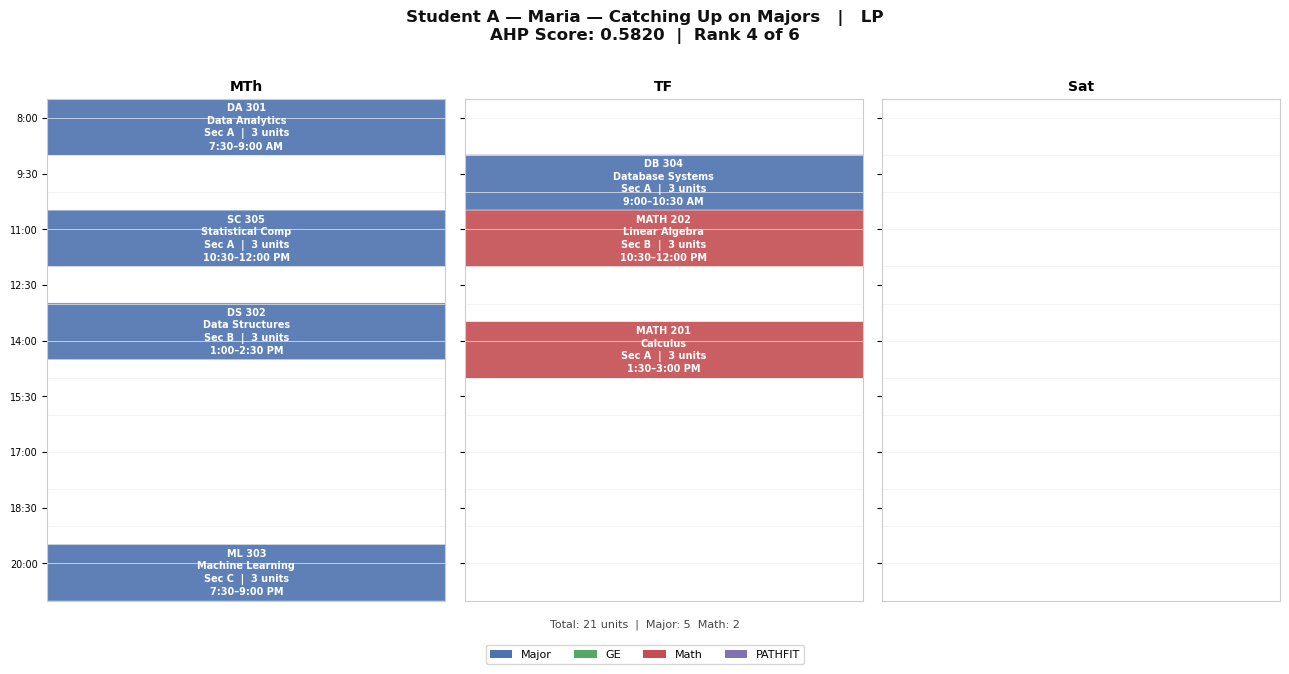

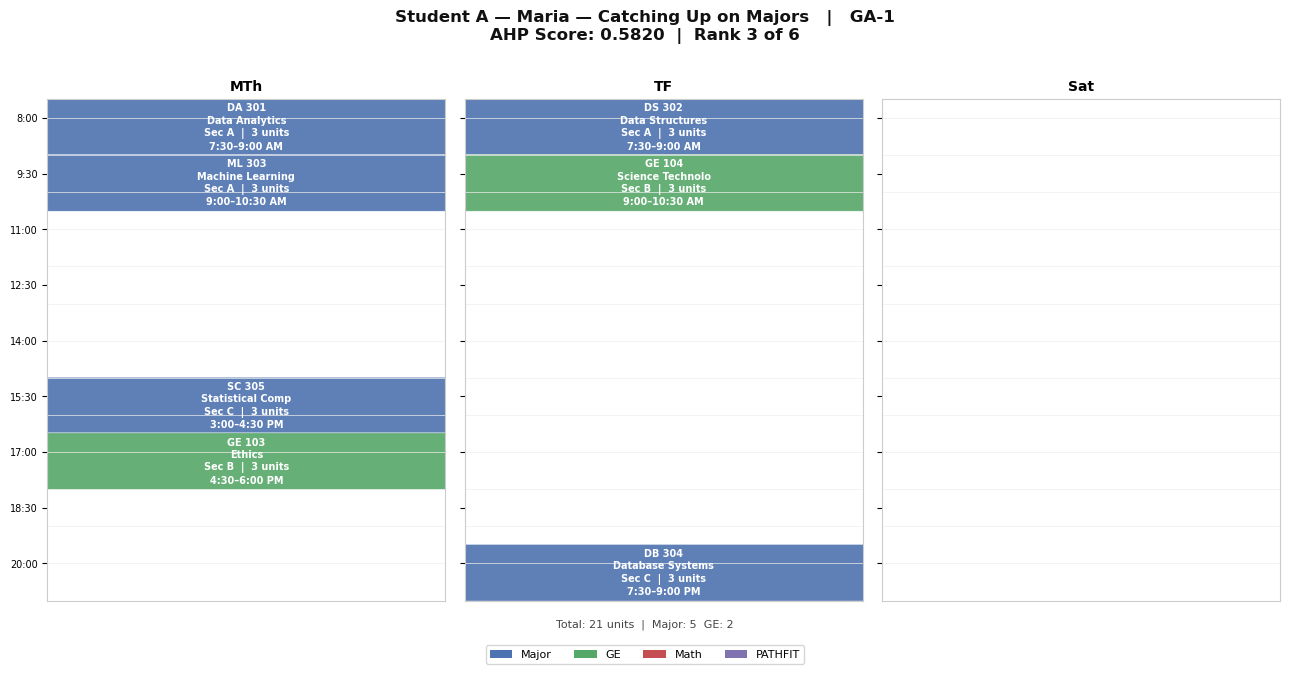

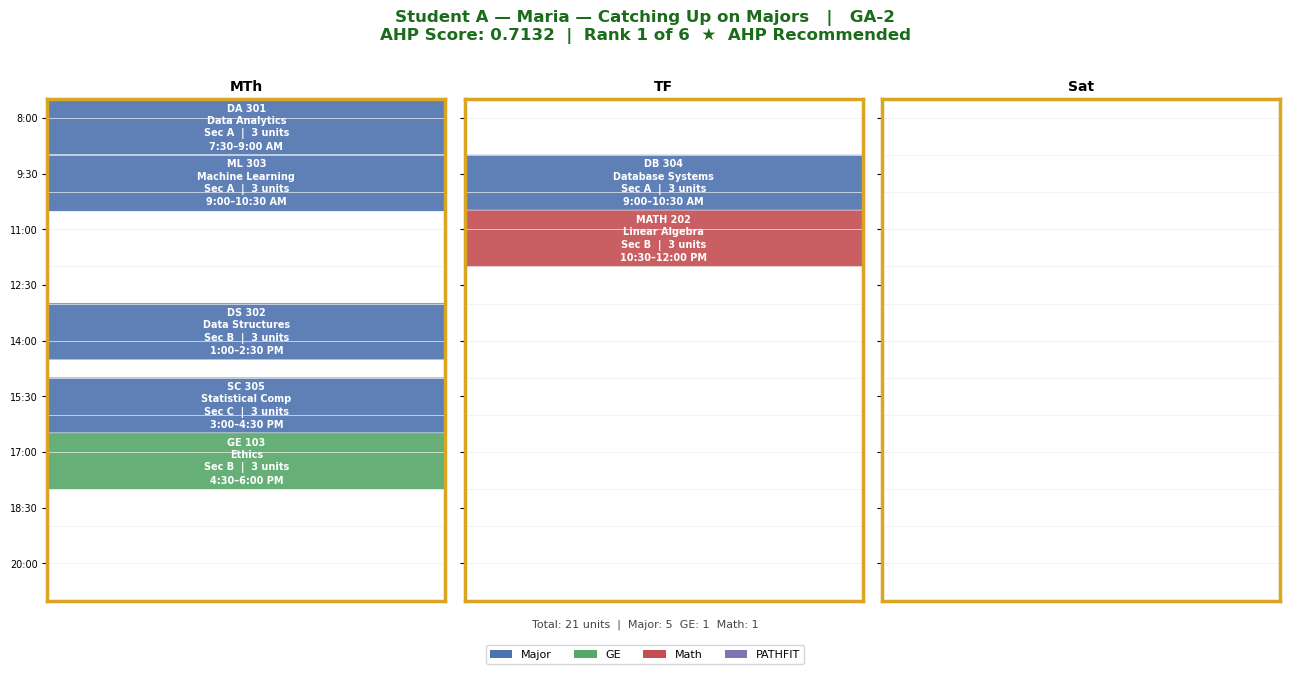

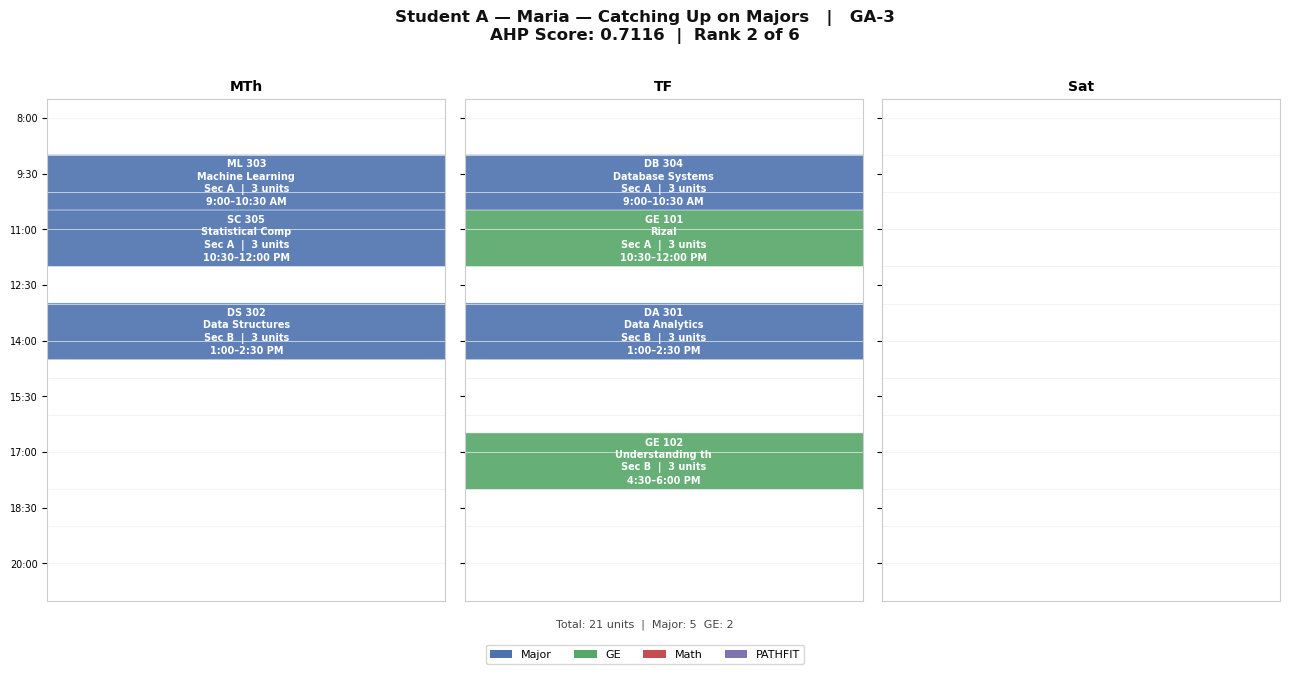

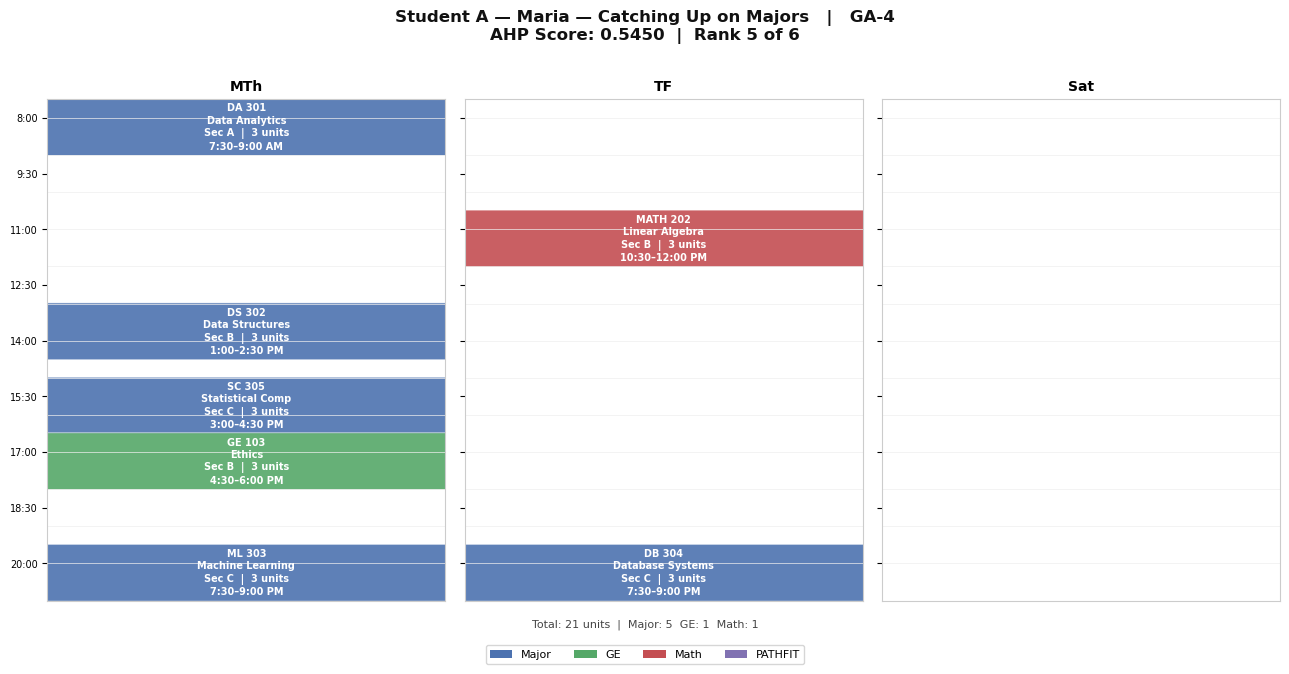

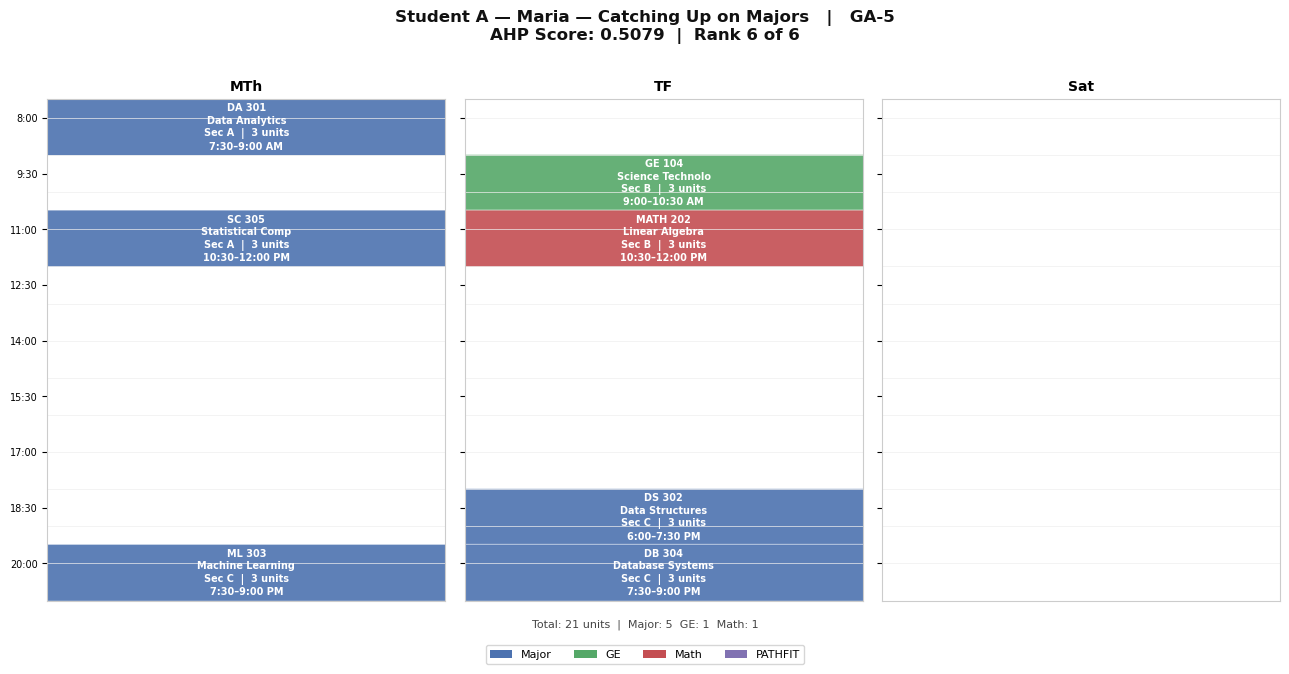


  Student B — Juan — Regular Balanced Student
  Profile: Wants balance; avoids Saturday and evening
  AHP Winner: GA-3



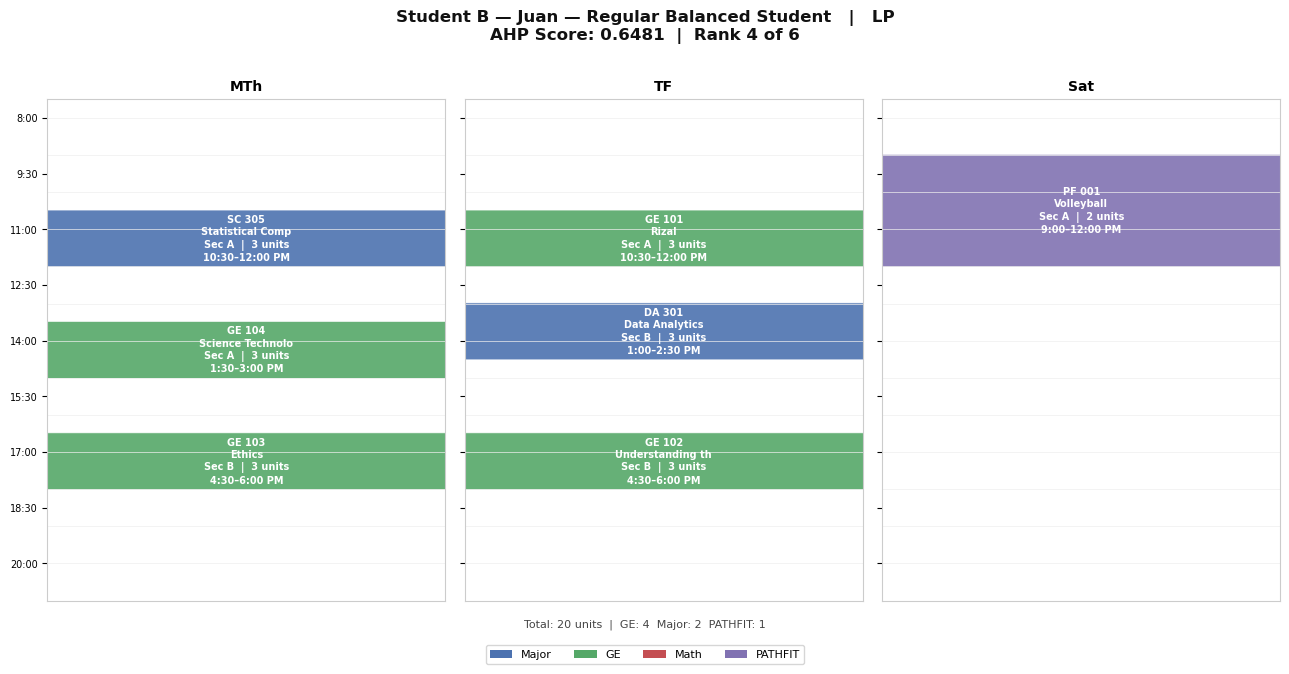

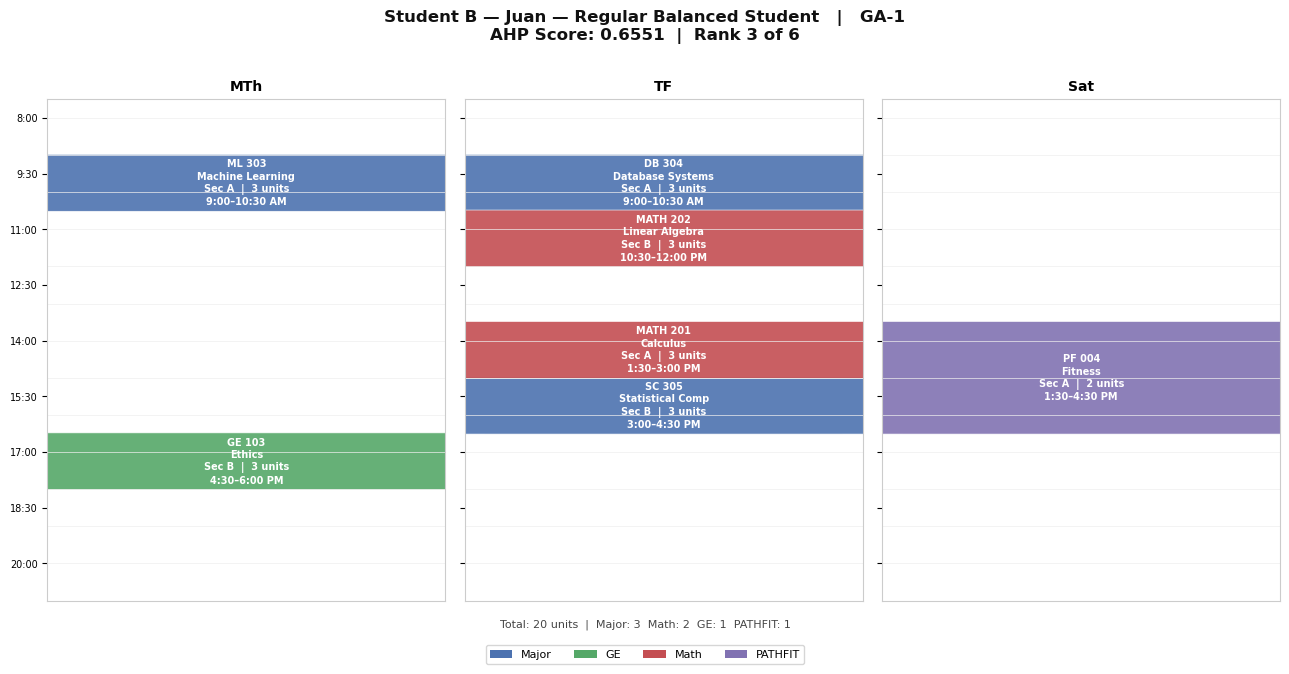

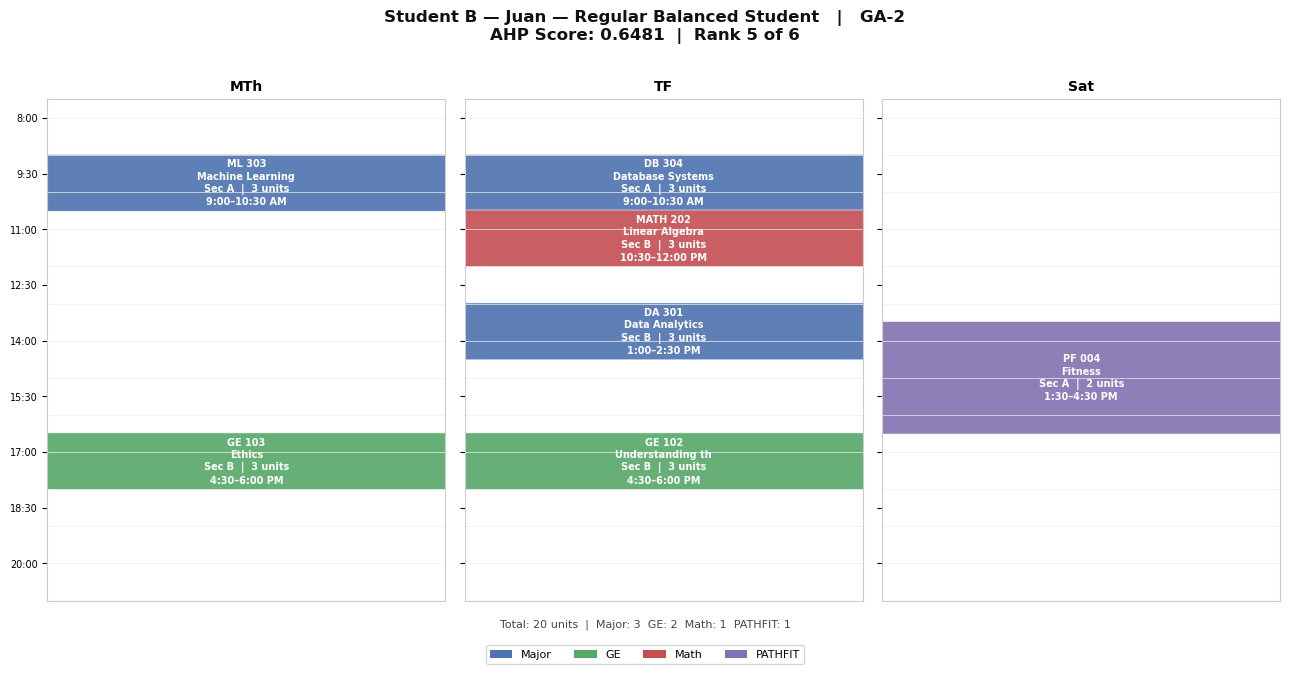

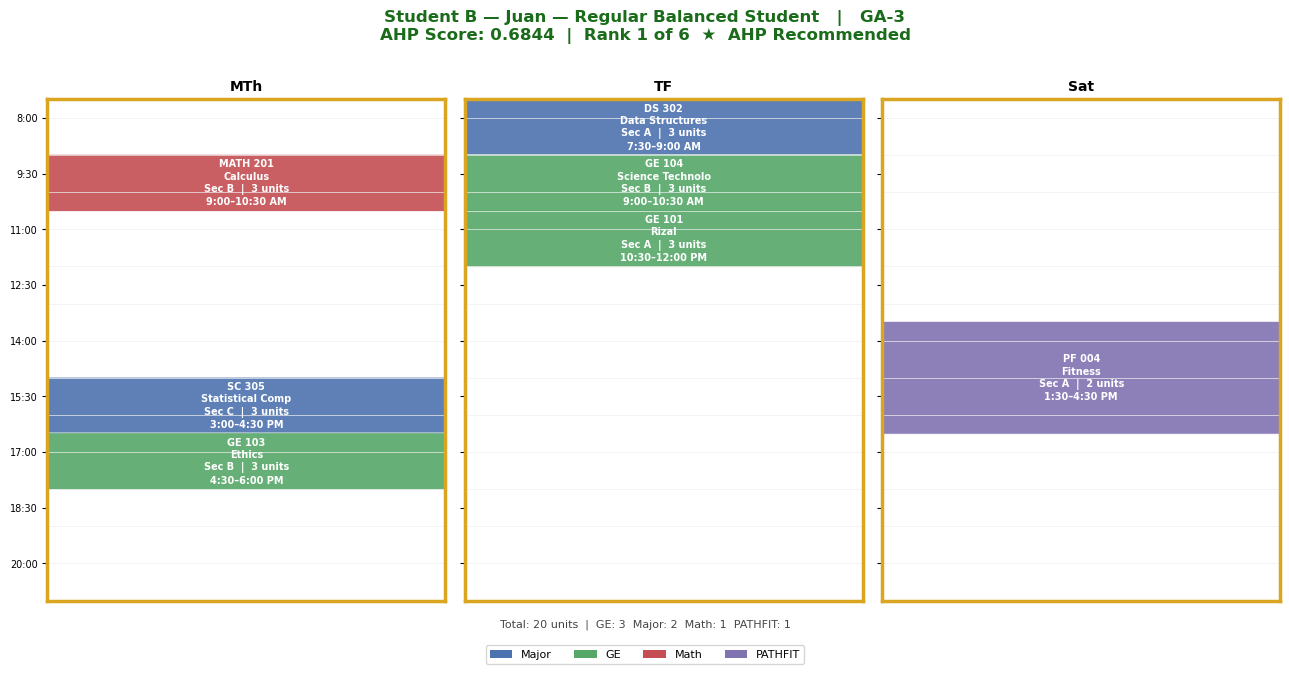

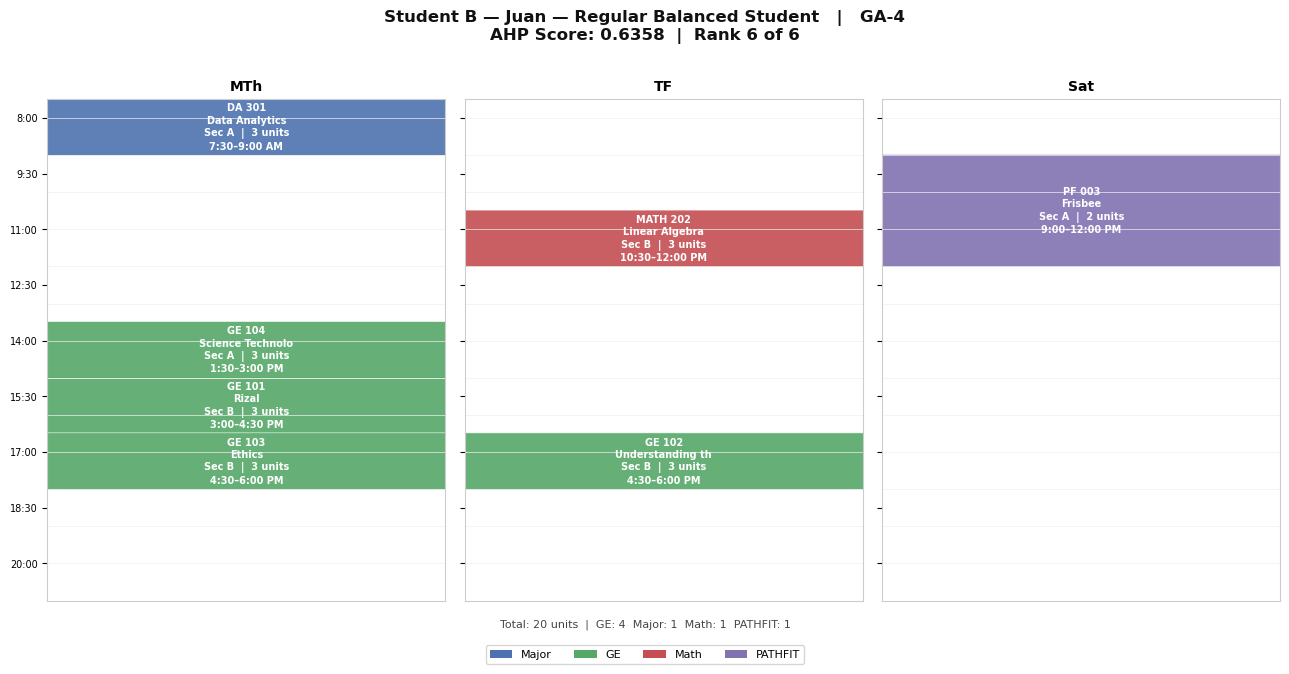

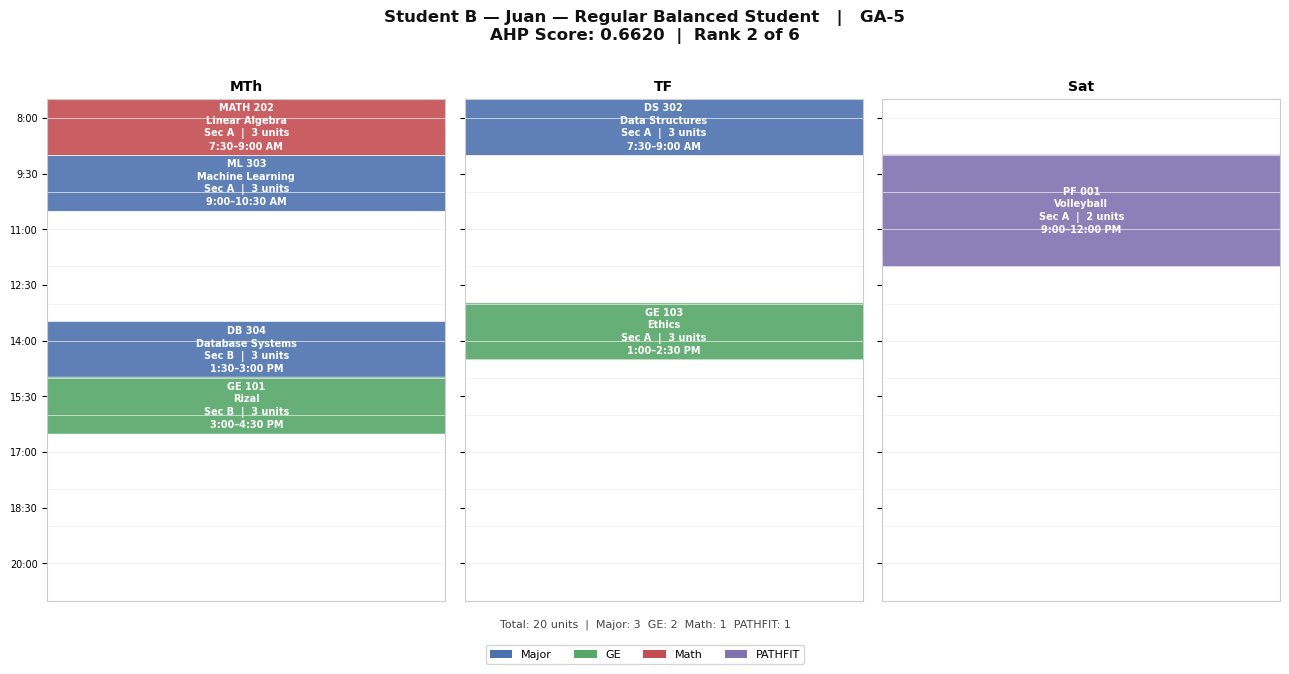


  Student C — Cardo — Shifter / Max Loader
  Profile: Wants maximum units; hates gaps between classes
  AHP Winner: GA-1



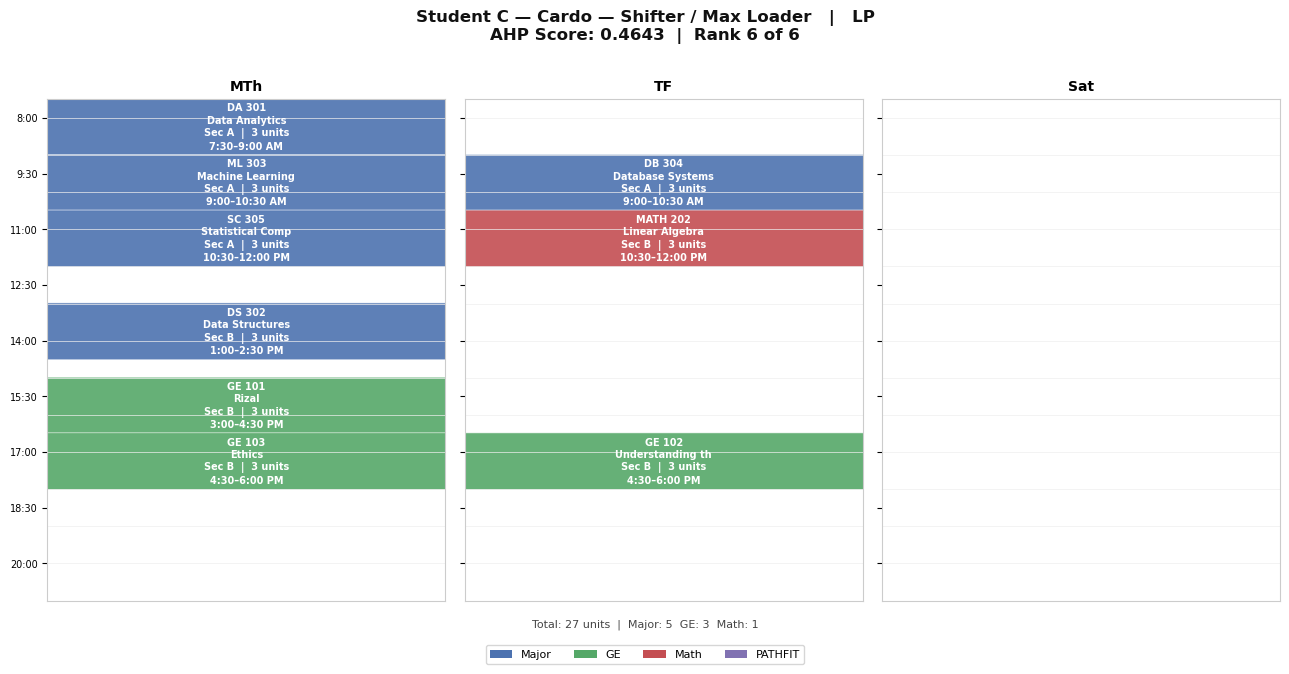

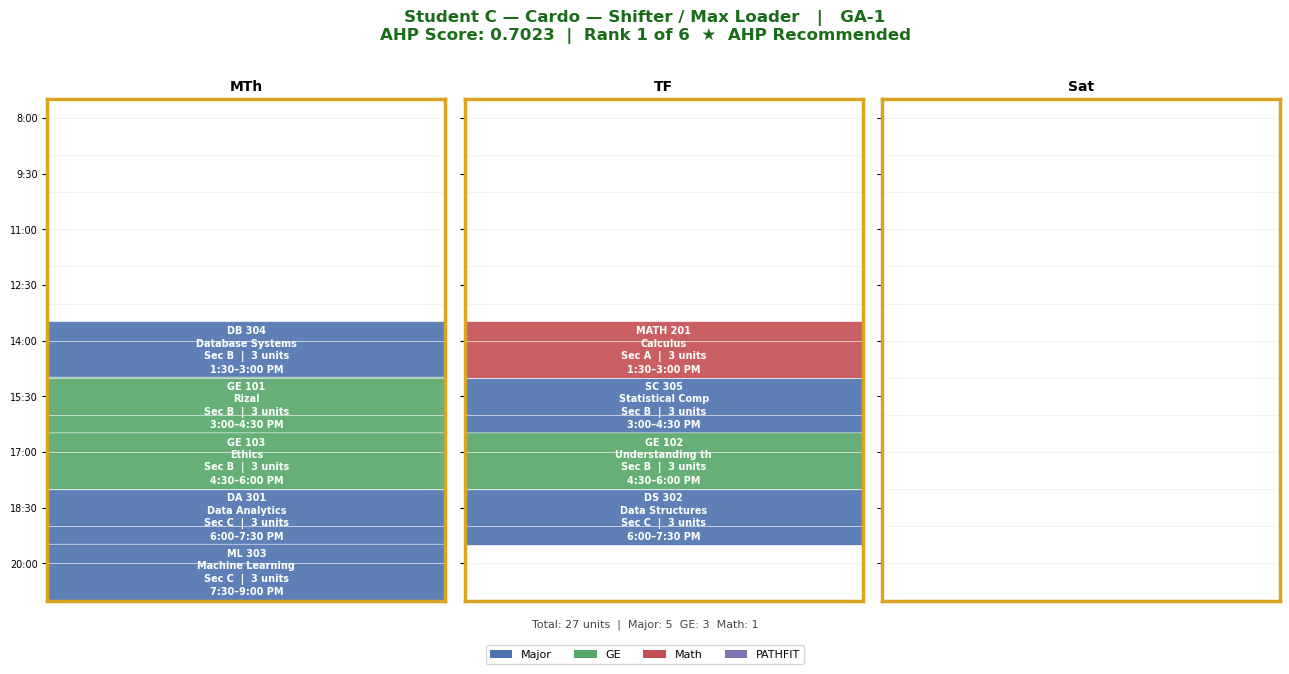

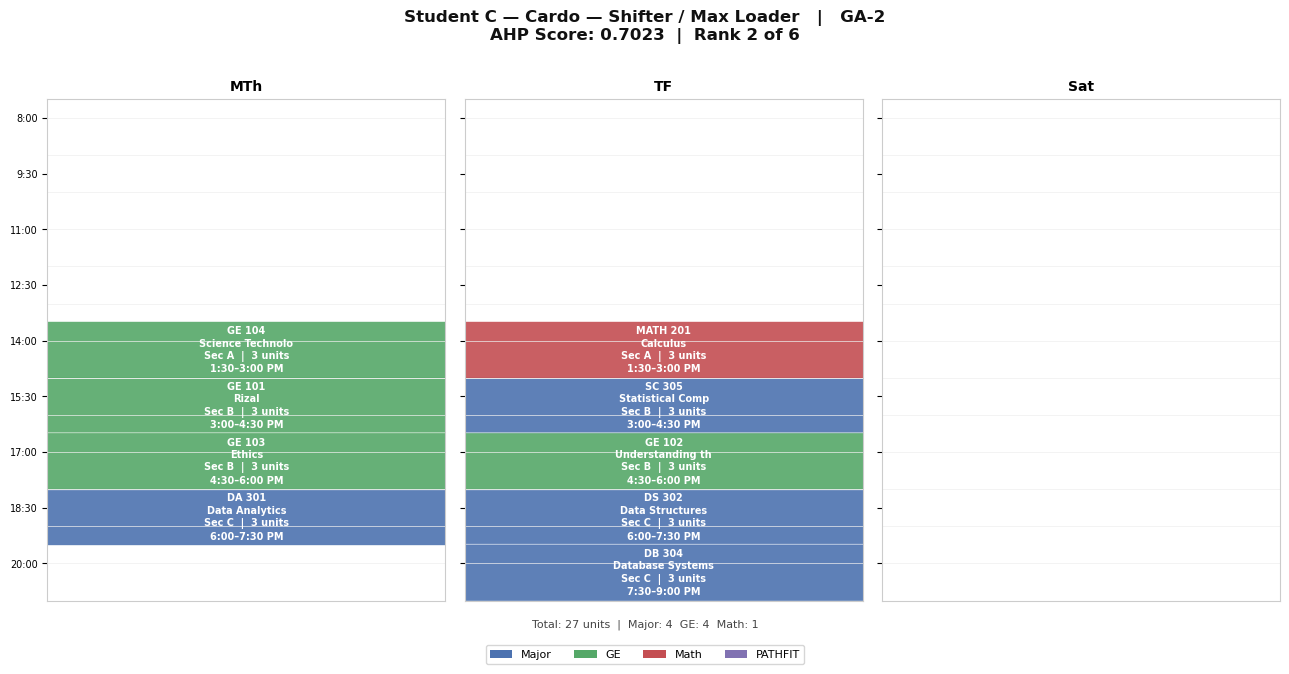

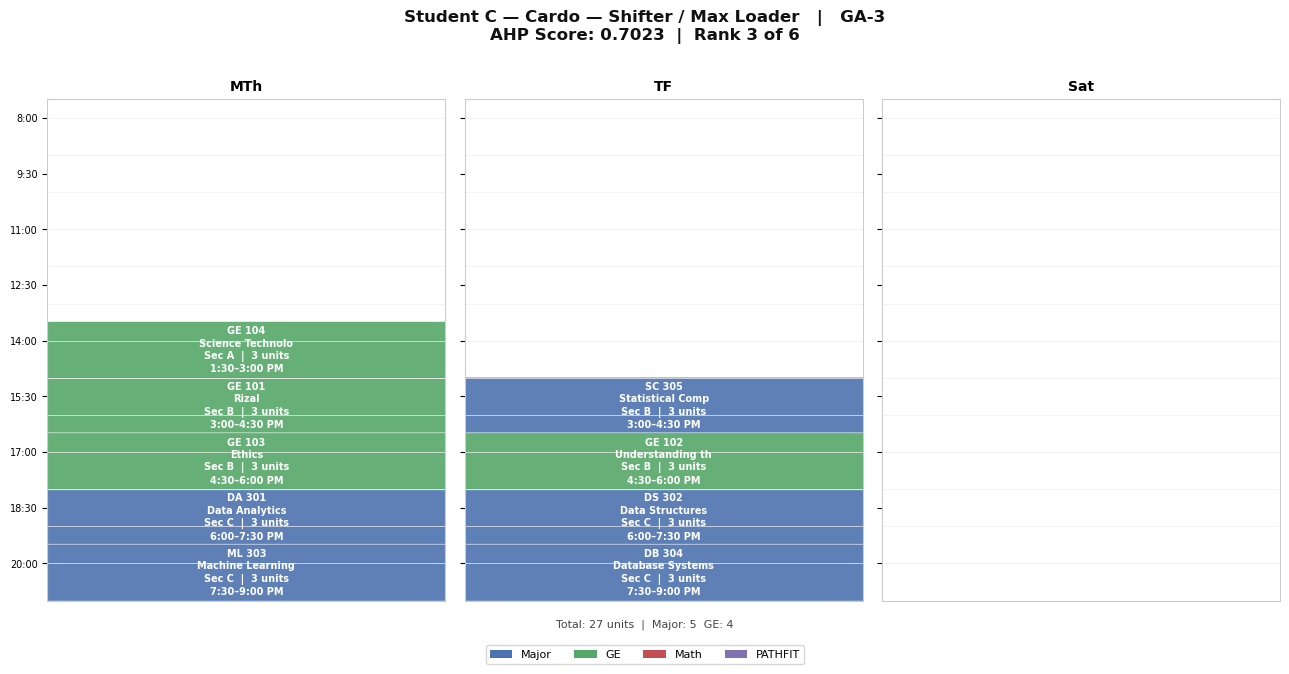

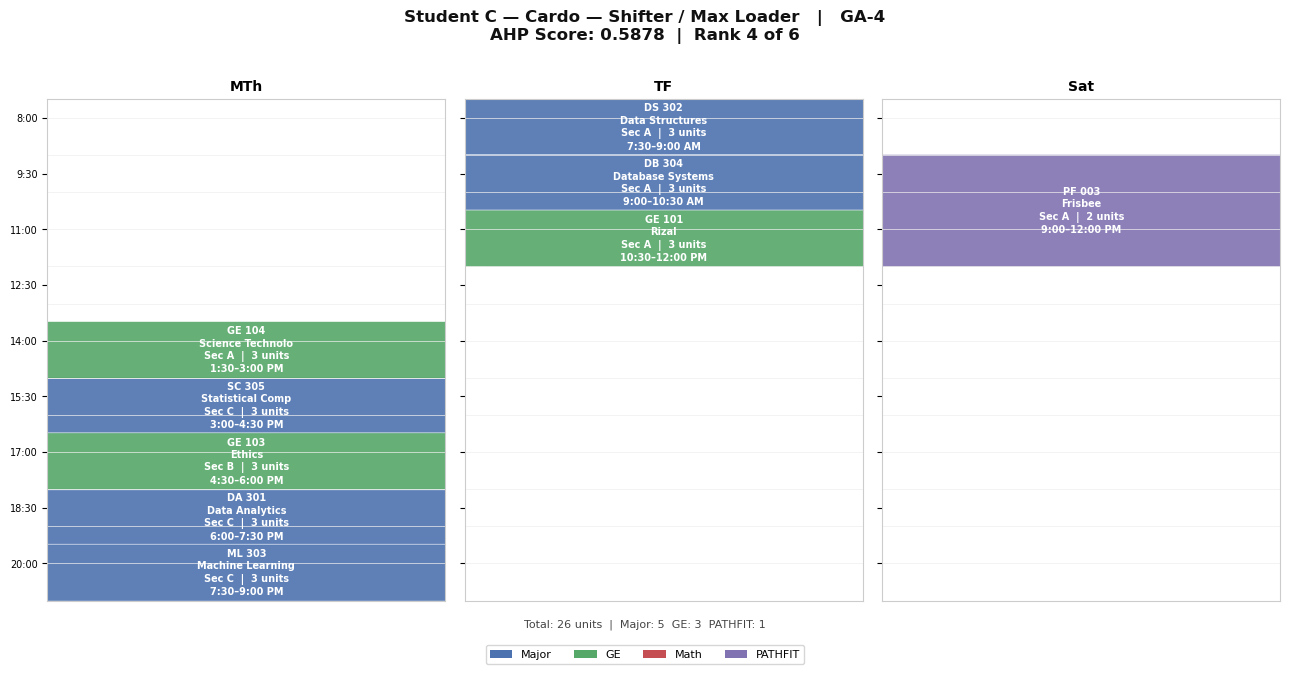

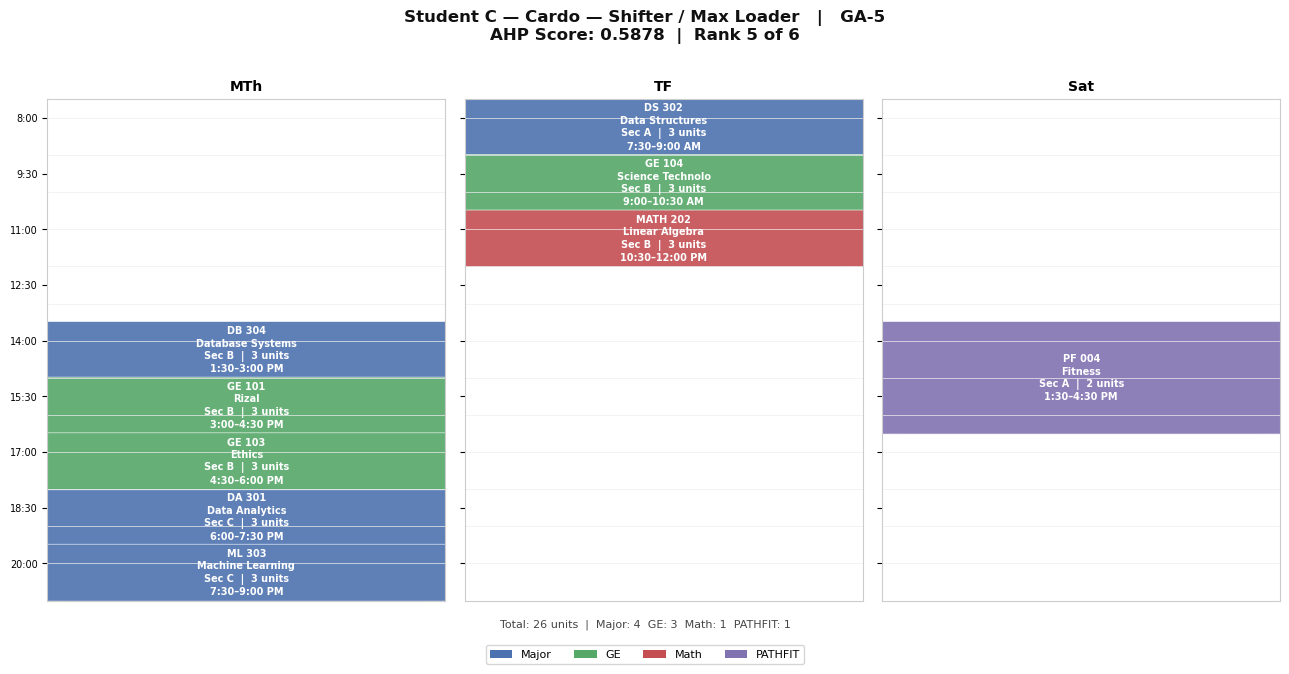

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared display settings ────────────────────────────────────────────────────
SCHED_COLORS = {
    'Major':   '#4C72B0',
    'GE':      '#55A868',
    'Math':    '#C44E52',
    'PATHFIT': '#8172B2',
}
DAY_COLS  = {'MTh': 0, 'TF': 1, 'Sat': 2}
DAY_LABELS = ['MTh', 'TF', 'Sat']
T_START = 7 * 60 + 30   # 7:30 AM
T_END   = 21 * 60        # 9:00 PM

legend_patches = [mpatches.Patch(facecolor=c, label=t) for t, c in SCHED_COLORS.items()]


def draw_schedule(sel_ids, main_title, sub_title, is_winner=False):
    """Draw one full timetable for a single candidate schedule."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 6), sharey=True)

    winner_tag = '  ★  AHP Recommended' if is_winner else ''
    fig.suptitle(
        f"{main_title}\n{sub_title}{winner_tag}",
        fontsize=12, fontweight='bold',
        color='#1a6b1a' if is_winner else '#111111',
        y=1.01
    )

    for col_idx, day_label in enumerate(DAY_LABELS):
        ax = axes[col_idx]
        ax.set_xlim(0, 1)
        ax.set_ylim(T_END, T_START)   # inverted: morning on top

        # Column header
        ax.set_title(day_label, fontsize=10, fontweight='bold', pad=6)

        # Hour grid lines
        for hr in range(8, 22):
            ax.axhline(hr * 60, color='#eeeeee', lw=0.5)

        # Draw classes that fall on this day
        day_ids = [i for i in sel_ids if df.iloc[i]['day_pattern'] == day_label]
        for idx in day_ids:
            row   = df.iloc[idx]
            color = SCHED_COLORS.get(row['subject_type'], '#aaaaaa')
            y0    = row['time_start_min']
            y1    = row['time_end_min']

            rect = mpatches.FancyBboxPatch(
                (0.05, y0 + 1), 0.90, (y1 - y0) - 2,
                boxstyle="round,pad=2", linewidth=0.5,
                facecolor=color, edgecolor='white', alpha=0.90
            )
            ax.add_patch(rect)

            label_text = (f"{row['course_code']}\n"
                          f"{row['subject_title'][:16]}\n"
                          f"Sec {row['section']}  |  {row['units']} units\n"
                          f"{row['time_slot']}")
            ax.text(0.5, (y0 + y1) / 2, label_text,
                    ha='center', va='center', fontsize=7,
                    color='white', fontweight='bold', linespacing=1.3)

        # Y-axis time ticks (left panel only)
        yticks = list(range(8 * 60, 21 * 60 + 1, 90))
        ax.set_yticks(yticks)
        if col_idx == 0:
            ax.set_yticklabels([f"{m // 60}:{m % 60:02d}" for m in yticks], fontsize=7)
        ax.set_xticks([])

        # Gold border for AHP winner
        for spine in ax.spines.values():
            spine.set_edgecolor('#DAA520' if is_winner else '#cccccc')
            spine.set_linewidth(2.5 if is_winner else 0.8)

    # Summary bar at bottom
    total_u  = sum(df.iloc[i]['units'] for i in sel_ids)
    type_cnt = df.iloc[sel_ids]['subject_type'].value_counts().to_dict()
    summary  = f"Total: {total_u} units  |  " + "  ".join(f"{k}: {v}" for k, v in type_cnt.items())
    fig.text(0.5, -0.02, summary, ha='center', fontsize=8, color='#444444')

    fig.legend(handles=legend_patches, loc='lower center',
               ncol=4, fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.09))

    plt.tight_layout()
    plt.show()


# ── Render all schedules grouped by student ────────────────────────────────────
for sid in ['A', 'B', 'C']:
    profile    = STUDENTS[sid]
    ranking_df, candidates = ahp_rankings[sid]
    best_label = ranking_df.iloc[0]['Candidate']

    print(f"\n{'='*65}")
    print(f"  Student {sid} — {profile['name']}")
    print(f"  Profile: {profile['ahp_label']}")
    print(f"  AHP Winner: {best_label}")
    print(f"{'='*65}\n")

    for label, sel_ids in candidates:
        is_winner = (label == best_label)
        ahp_row   = ranking_df[ranking_df['Candidate'] == label]
        ahp_score = ahp_row['AHP Score'].values[0] if len(ahp_row) else 0.0
        rank      = ahp_row.index[0] if len(ahp_row) else '?'
        sub = f"AHP Score: {ahp_score:.4f}  |  Rank {rank} of {len(candidates)}"
        draw_schedule(
            sel_ids,
            f"Student {sid} — {profile['name']}   |   {label}",
            sub,
            is_winner
        )

---

## 9. Integration — How the Two Methods Work Together

This is the core of the prescriptive analytics approach. Each method plays a specific role:

```
┌─────────────────────────────────────────────────────────────────────┐
│                     FULL PIPELINE                                   │
│                                                                     │
│  DATASET (35 class offerings)                                       │
│       ↓                                                             │
│  ┌─────────────┐      ┌─────────────────────────────────────┐       │
│  │     LP      │      │          GA (run × 5 seeds)         │       │
│  │  (1 result) │      │         (5 distinct results)        │       │
│  └──────┬──────┘      └────────────────┬────────────────────┘       │
│         └──────────────────────────────┘                            │
│                           ↓                                         │
│              6 candidate schedules per student                      │
│                           ↓                                         │
│         ┌─────────────────────────────────┐                         │
│         │  AHP (5 criteria, per-student   │                         │
│         │       pairwise weights)         │                         │
│         └────────────────┬────────────────┘                         │
│                          ↓                                          │
│               Best schedule per student                             │
└─────────────────────────────────────────────────────────────────────┘
```

### Why combining is better than using one method alone

| Using only LP | Using only GA | Using only AHP |
|---------------|---------------|----------------|
| One answer — no alternatives | Many answers — no ranking | No way to generate candidates |
| Cannot express "prefer mornings" | Cannot guarantee optimality | Needs inputs from somewhere |
| No diversity in solutions | May not match student objective | Depends on LP + GA |

**Together:**
- LP ensures at least one mathematically optimal answer exists
- GA provides diversity — different valid schedules to compare
- AHP adds personalization — it knows what the student actually values

This is the essence of prescriptive analytics: not just finding a valid answer, but recommending the **right** answer for the specific person.

---

## 10. Results

For each student, we show:
1. The **recommended schedule** (winner from AHP)
2. A summary of units, gaps, and time preferences met
3. A **visual timetable grid** showing the weekly schedule
4. A brief explanation of why this schedule fits the student


STUDENT A — Maria — Catching Up on Majors
Recommended by: GA-2  |  AHP Score: 0.7132
course_code         subject_title subject_type  units section day_pattern      time_slot      instructor
     DS 302       Data Structures        Major      3       B         MTh   1:00–2:30 PM    Prof. Garcia
     SC 305 Statistical Computing        Major      3       C         MTh   3:00–4:30 PM Prof. Dela Cruz
     GE 103                Ethics           GE      3       B         MTh   4:30–6:00 PM  Prof. Bautista
     DA 301        Data Analytics        Major      3       A         MTh   7:30–9:00 AM   Prof. Pascual
     ML 303      Machine Learning        Major      3       A         MTh  9:00–10:30 AM   Prof. Pascual
   MATH 202        Linear Algebra         Math      3       B          TF 10:30–12:00 PM   Prof. Navarro
     DB 304      Database Systems        Major      3       A          TF  9:00–10:30 AM Prof. Dela Cruz

  Total units   : 21
  Major units   : 15
  Gap count     : 2  (total gap

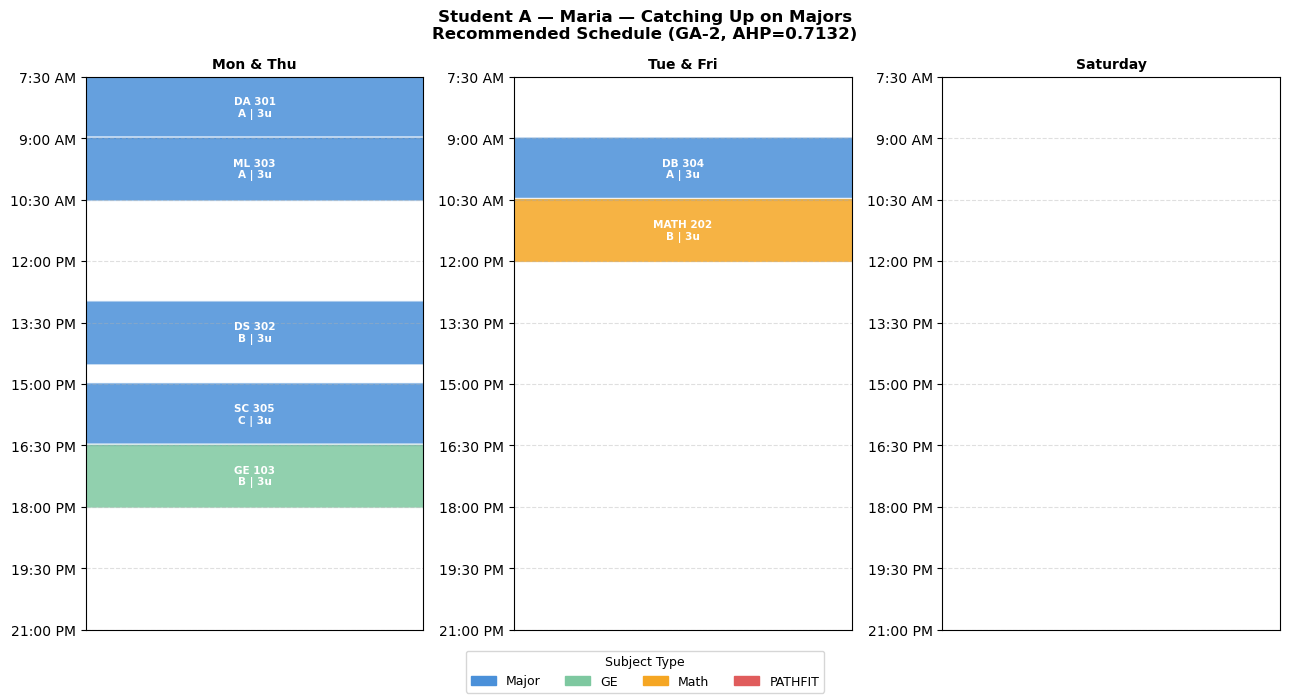


Why this schedule fits Student A:
  Maria's schedule focuses almost entirely on major subjects (15 out of 21 units). Because AHP weighted subject-type match highest for her profile, the system selected the candidate with the greatest concentration of major courses. She has 2 gap(s) between classes, which is acceptable since she is flexible about schedule timing.

STUDENT B — Juan — Regular Balanced Student
Recommended by: GA-3  |  AHP Score: 0.6844
course_code              subject_title subject_type  units section day_pattern      time_slot      instructor
     SC 305      Statistical Computing        Major      3       C         MTh   3:00–4:30 PM Prof. Dela Cruz
     GE 103                     Ethics           GE      3       B         MTh   4:30–6:00 PM  Prof. Bautista
   MATH 201                   Calculus         Math      3       B         MTh  9:00–10:30 AM      Prof. Cruz
     PF 004                    Fitness      PATHFIT      2       A         Sat   1:30–4:30 PM    Prof. Tor

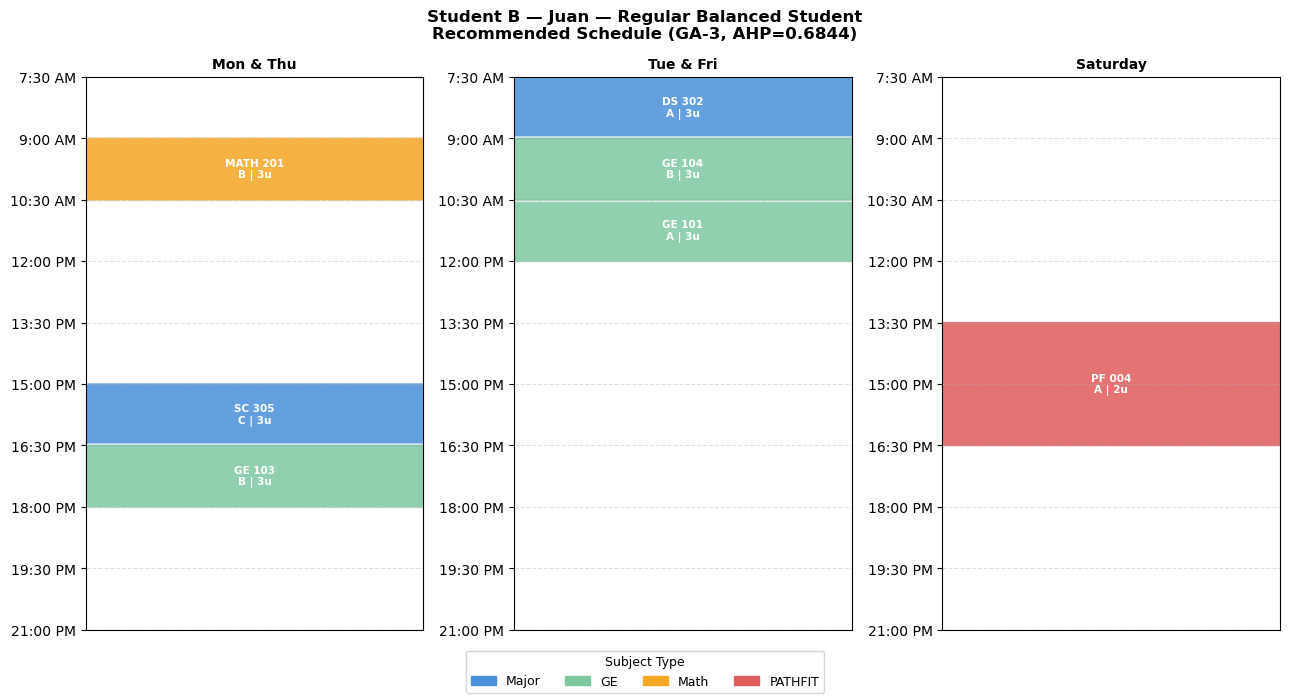


Why this schedule fits Student B:
  Juan's schedule is balanced across subject types, includes a PATHFIT class, and avoids Saturday and evening slots. With 1 Saturday and 0 evening class(es), this schedule gives him a comfortable weekday routine. AHP selected this candidate because it scored highest on sat_avoid and eve_avoid — exactly what Juan values most.

STUDENT C — Cardo — Shifter / Max Loader
Recommended by: GA-1  |  AHP Score: 0.7023
course_code          subject_title subject_type  units section day_pattern    time_slot      instructor
     DB 304       Database Systems        Major      3       B         MTh 1:30–3:00 PM Prof. Dela Cruz
     GE 101                  Rizal           GE      3       B         MTh 3:00–4:30 PM Prof. Dela Cruz
     GE 103                 Ethics           GE      3       B         MTh 4:30–6:00 PM  Prof. Bautista
     DA 301         Data Analytics        Major      3       C         MTh 6:00–7:30 PM   Prof. Mendoza
     ML 303       Machine Learnin

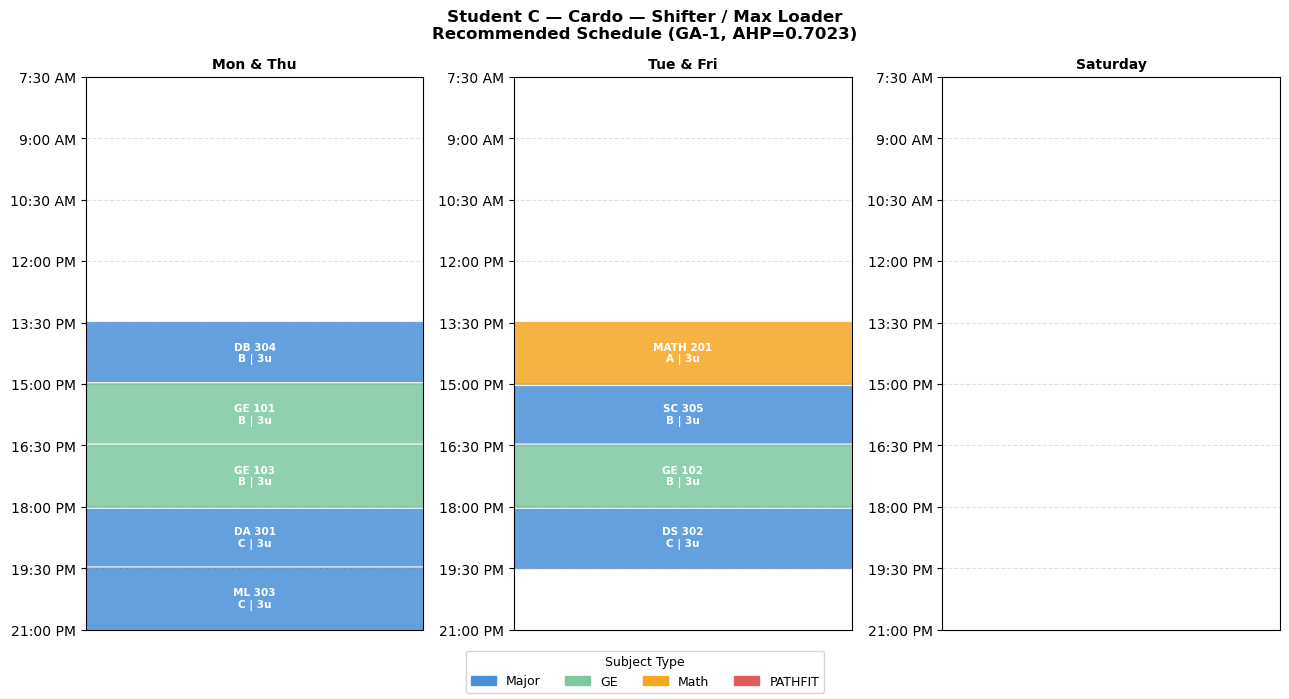


Why this schedule fits Student C:
  Cardo's schedule packs in 27 units — close to his 27-unit maximum. AHP selected this candidate primarily because it scored best on gap_score and compactness, minimizing the idle time between his classes. With only 0 gap(s) and a total gap time of 0 minutes, this is the most efficient schedule available for his commuting situation.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# ── Color map for subject types ────────────────────────────────────────────────
TYPE_COLORS = {
    "Major":   "#4A90D9",   # blue
    "GE":      "#7EC8A0",   # green
    "Math":    "#F5A623",   # orange
    "PATHFIT": "#E05C5C",   # red
}

# ── Timetable grid ─────────────────────────────────────────────────────────────
def draw_timetable(selected_ids, student_name, ax_list):
    """
    Draw a weekly timetable on 3 axes (MTh, TF, Sat).
    ax_list = [ax_mth, ax_tf, ax_sat]
    """
    rows_sel = df.iloc[list(selected_ids)]

    # Time axis: 7:30 AM (450 min) to 9:00 PM (1260 min)
    t_start_axis = 7*60 + 30
    t_end_axis   = 21*60
    t_range      = t_end_axis - t_start_axis

    day_labels = {"MTh": "Mon & Thu", "TF": "Tue & Fri", "Sat": "Saturday"}
    axes_map   = {"MTh": ax_list[0], "TF": ax_list[1], "Sat": ax_list[2]}

    for day_pat, ax in axes_map.items():
        ax.set_xlim(0, 1)
        ax.set_ylim(t_end_axis, t_start_axis)  # inverted (top=morning)
        ax.set_title(day_labels[day_pat], fontsize=10, fontweight='bold')
        ax.set_xticks([])
        ax.yaxis.set_major_locator(ticker.MultipleLocator(90))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(
            lambda m, _: f"{int(m)//60}:{'00' if int(m)%60==0 else int(m)%60} {'AM' if int(m)<12*60 else 'PM'}"
        ))
        ax.grid(axis='y', linestyle='--', alpha=0.4)

        day_classes = rows_sel[rows_sel['day_pattern'] == day_pat]
        for _, row in day_classes.iterrows():
            s = row['time_start_min']
            e = row['time_end_min']
            color = TYPE_COLORS.get(row['subject_type'], '#CCCCCC')
            rect = mpatches.FancyBboxPatch(
                (0.05, s), 0.90, e - s,
                boxstyle="round,pad=2", linewidth=1,
                edgecolor='white', facecolor=color, alpha=0.85
            )
            ax.add_patch(rect)
            label = f"{row['course_code']}\n{row['section']} | {row['units']}u"
            ax.text(0.5, (s + e) / 2, label,
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold',
                    wrap=True)


def show_student_result(student_id):
    profile   = STUDENTS[student_id]
    sel_ids   = best_schedules[student_id]
    feat      = schedule_features(sel_ids)
    sched_df  = df.iloc[sel_ids][['course_code','subject_title','subject_type',
                                   'units','section','day_pattern','time_slot','instructor']]
    sched_df  = sched_df.sort_values(['day_pattern','time_slot']).reset_index(drop=True)

    # AHP winner label
    ranking_df, _ = ahp_rankings[student_id]
    winner_label  = ranking_df.iloc[0]['Candidate']
    ahp_score     = ranking_df.iloc[0]['AHP Score']

    print(f"\n{'='*65}")
    print(f"STUDENT {student_id} — {profile['name']}")
    print(f"Recommended by: {winner_label}  |  AHP Score: {ahp_score}")
    print(f"{'='*65}")
    print(sched_df.to_string(index=False))
    print(f"\n  Total units   : {feat['total_units']}")
    print(f"  Major units   : {feat['major_units']}")
    print(f"  Gap count     : {feat['gap_count']}  (total gap: {feat['total_gap_min']} min)")
    print(f"  Saturday class: {feat['sat_count']}")
    print(f"  Evening class : {feat['eve_count']}")

    # Draw timetable
    fig, axes = plt.subplots(1, 3, figsize=(13, 7), sharey=False)
    fig.suptitle(f"Student {student_id} — {profile['name']}\nRecommended Schedule ({winner_label}, AHP={ahp_score})",
                 fontsize=12, fontweight='bold')

    draw_timetable(sel_ids, profile['name'], axes)

    # Legend
    patches = [mpatches.Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=9,
               title="Subject Type", title_fontsize=9, framealpha=0.8)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()

    # Narrative
    narratives = {
        "A": (f"Maria's schedule focuses almost entirely on major subjects ({feat['major_units']} out of "
              f"{feat['total_units']} units). Because AHP weighted subject-type match highest for her profile, "
              f"the system selected the candidate with the greatest concentration of major courses. "
              f"She has {feat['gap_count']} gap(s) between classes, which is acceptable since she is flexible "
              f"about schedule timing."),
        "B": (f"Juan's schedule is balanced across subject types, includes a PATHFIT class, and avoids "
              f"Saturday and evening slots. With {feat['sat_count']} Saturday and {feat['eve_count']} evening class(es), "
              f"this schedule gives him a comfortable weekday routine. AHP selected this candidate because "
              f"it scored highest on sat_avoid and eve_avoid — exactly what Juan values most."),
        "C": (f"Cardo's schedule packs in {feat['total_units']} units — close to his 27-unit maximum. "
              f"AHP selected this candidate primarily because it scored best on gap_score and compactness, "
              f"minimizing the idle time between his classes. With only {feat['gap_count']} gap(s) and a "
              f"total gap time of {feat['total_gap_min']} minutes, this is the most efficient schedule "
              f"available for his commuting situation."),
    }
    print(f"\nWhy this schedule fits Student {student_id}:")
    print(f"  {narratives[student_id]}")


for sid in ['A','B','C']:
    show_student_result(sid)

---

## 11. Comparison and Analysis

Here we compare how each method performed, and whether combining them produced a better result than using just one method.

For each student, we compare:
- **LP result** — the mathematically optimal schedule
- **Best GA result** — the top-scoring GA candidate
- **AHP winner** — the candidate recommended by AHP

We also show a bar chart of AHP scores for all 6 candidates to visualize how clearly one candidate won.

COMPARISON TABLE — LP vs GA-Best vs AHP Winner

─────────────────────────────────────────────────────────────────
Student A — Maria — Catching Up on Majors
          Total Units  Major Units  Type Count  Gaps  Gap Minutes  Sat Classes  Eve Classes  AHP Score
Source                                                                                                
LP                 21           15           2     4          540            0            1      0.582
GA-1               21           15           2     2          810            0            1      0.582
AHP→GA-2           21           15           3     2          180            0            0        NaN

─────────────────────────────────────────────────────────────────
Student B — Juan — Regular Balanced Student
          Total Units  Major Units  Type Count  Gaps  Gap Minutes  Sat Classes  Eve Classes  AHP Score
Source                                                                                                
LP          

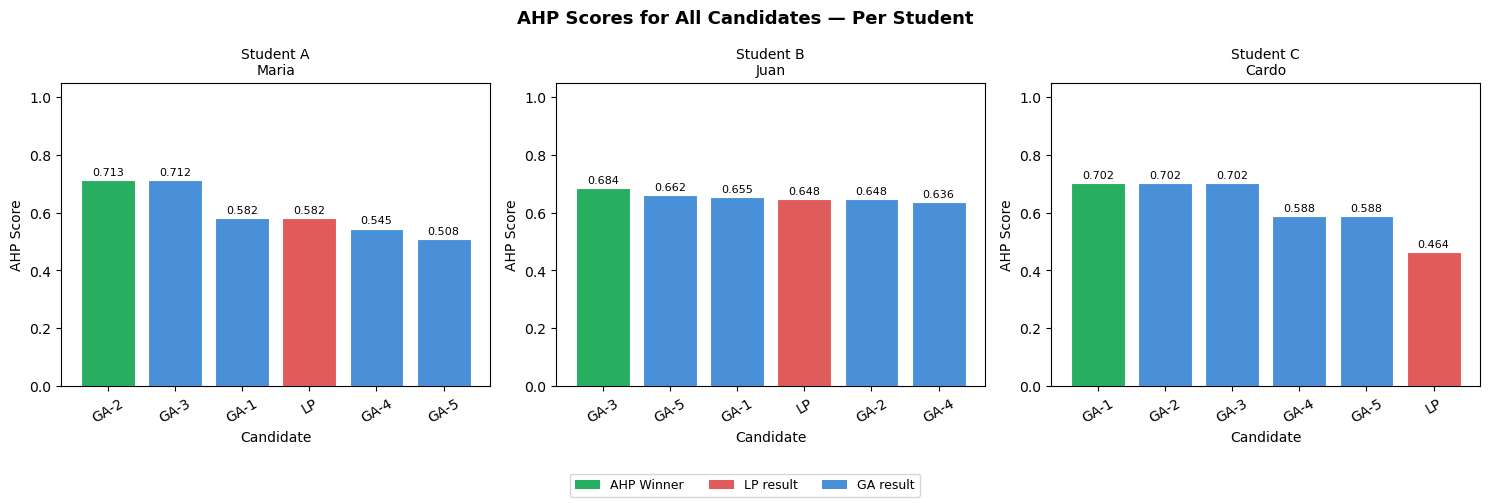


KEY OBSERVATIONS:

Accuracy / Optimality
─────────────────────
LP always satisfies the mathematical objective perfectly (e.g., Student A's LP result
maximizes major units exactly). However, LP doesn't account for soft preferences like
gap minimization or evening avoidance.

GA Flexibility
──────────────
GA produces a variety of valid schedules. Some GA candidates have fewer gaps or avoid
evening classes even when LP didn't consider those factors. This diversity is exactly
why AHP has meaningful choices to make.

AHP Value
─────────
AHP reveals that the "mathematically optimal" LP schedule is not always the best choice
for the student's actual situation. In cases where a GA candidate scores higher on the
criteria the student cares about, AHP correctly picks the GA result over LP.

Speed
─────
LP solves in under 1 second per student. GA takes a few seconds per run (200 generations).
AHP scoring is instant. The full pipeline per student runs in under 30 seconds.

Real-World Applicability

In [ ]:
# ── Side-by-side comparison table ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

def build_comparison_row(sel_ids, label, student_id):
    feat = schedule_features(sel_ids)
    ranking_df, _ = ahp_rankings[student_id]
    ahp_row = ranking_df[ranking_df['Candidate'] == label]
    ahp_score = ahp_row['AHP Score'].values[0] if len(ahp_row) > 0 else None
    return {
        "Source":        label,
        "Total Units":   feat['total_units'],
        "Major Units":   feat['major_units'],
        "Type Count":    feat['type_count'],
        "Gaps":          feat['gap_count'],
        "Gap Minutes":   feat['total_gap_min'],
        "Sat Classes":   feat['sat_count'],
        "Eve Classes":   feat['eve_count'],
        "AHP Score":     ahp_score,
    }

print("COMPARISON TABLE — LP vs GA-Best vs AHP Winner\n")
for sid in ['A','B','C']:
    print(f"{'─'*65}")
    print(f"Student {sid} — {STUDENTS[sid]['name']}")
    rows_cmp = []

    # LP
    if lp_results[sid]:
        rows_cmp.append(build_comparison_row(lp_results[sid], "LP", sid))

    # Best GA (first in the sorted list = highest fitness score)
    if ga_results[sid]:
        rows_cmp.append(build_comparison_row(ga_results[sid][0], "GA-1", sid))

    # AHP winner
    best_label = ahp_rankings[sid][0].iloc[0]['Candidate']
    best_ids   = best_schedules[sid]
    if best_label not in ["LP", "GA-1"]:
        rows_cmp.append(build_comparison_row(best_ids, f"AHP→{best_label}", sid))

    cmp_df = pd.DataFrame(rows_cmp).set_index("Source")
    print(cmp_df.to_string())
    print()


# ── Bar chart: AHP scores for all 6 candidates ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("AHP Scores for All Candidates — Per Student", fontsize=13, fontweight='bold')

bar_colors = {
    "LP": "#E05C5C",
    "GA-1": "#4A90D9", "GA-2": "#4A90D9", "GA-3": "#4A90D9",
    "GA-4": "#4A90D9", "GA-5": "#4A90D9",
}

for idx, sid in enumerate(['A','B','C']):
    ax = axes[idx]
    ranking_df, _ = ahp_rankings[sid]
    labels = ranking_df['Candidate'].tolist()
    scores = ranking_df['AHP Score'].tolist()
    colors = [("#E05C5C" if l == "LP" else "#4A90D9") for l in labels]
    # Highlight winner
    winner = ranking_df.iloc[0]['Candidate']
    colors = [("#27AE60" if l == winner else c) for l, c in zip(labels, colors)]

    bars = ax.bar(labels, scores, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f"Student {sid}\n{STUDENTS[sid]['name'].split('—')[0].strip()}", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("AHP Score")
    ax.set_xlabel("Candidate")
    ax.tick_params(axis='x', rotation=30)
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{score:.3f}", ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#27AE60', label='AHP Winner'),
    Patch(facecolor='#E05C5C', label='LP result'),
    Patch(facecolor='#4A90D9', label='GA result'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=9, framealpha=0.8)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


# ── Discussion ─────────────────────────────────────────────────────────────────
print("\nKEY OBSERVATIONS:")
print("""
Accuracy / Optimality
─────────────────────
LP always satisfies the mathematical objective perfectly (e.g., Student A's LP result
maximizes major units exactly). However, LP doesn't account for soft preferences like
gap minimization or evening avoidance.

GA Flexibility
──────────────
GA produces a variety of valid schedules. Some GA candidates have fewer gaps or avoid
evening classes even when LP didn't consider those factors. This diversity is exactly
why AHP has meaningful choices to make.

AHP Value
─────────
AHP reveals that the "mathematically optimal" LP schedule is not always the best choice
for the student's actual situation. In cases where a GA candidate scores higher on the
criteria the student cares about, AHP correctly picks the GA result over LP.

Speed
─────
LP solves in under 1 second per student. GA takes a few seconds per run (200 generations).
AHP scoring is instant. The full pipeline per student runs in under 30 seconds.

Real-World Applicability
────────────────────────
This system can scale to real university datasets with hundreds of class offerings.
The main bottleneck would be GA runtime, which can be parallelized or reduced with
smaller population sizes for larger datasets.
""")

---

## 12. Conclusion

### What we built

We built a complete prescriptive analytics system that automatically generates and recommends class schedules for three different types of students.

The system works in three steps:

1. **LP** finds the single mathematically optimal schedule per student based on their specific goal (maximize major units, maximize diversity, or maximize total load).

2. **GA** explores the space of valid schedules and produces 5 diverse alternatives per student. Each alternative follows all hard constraints but may differ in gap distribution, time preferences, and subject mix.

3. **AHP** compares all 6 candidates (1 LP + 5 GA) per student using 5 criteria that reflect the student's actual preferences. It selects the final recommended schedule.

---

### Key insight: Why combining methods is effective

Using only LP would give us a mathematically correct answer, but it cannot factor in preferences like "avoid Saturday classes" or "minimize gaps." LP optimizes one thing at a time.

Using only GA would give us many options but no principled way to choose among them. The highest-fitness GA solution might still not be the best match for the student's lifestyle.

Using only AHP would be impossible — it needs a set of candidates to compare. It cannot generate schedules on its own.

**Together, the three methods complement each other perfectly:**
- LP ensures quality (at least one strong baseline)
- GA ensures variety (diverse pool of valid options)
- AHP ensures personalization (picks the right one for each individual)

This is prescriptive analytics at its core: **not just finding answers, but deciding the best action for a specific person in a specific situation.**

---

### Best approach

For this problem, the combined **LP → GA → AHP pipeline** is the best approach. It is more robust than any single method and produces schedules that are both valid and genuinely suited to each student's needs.

---

## 13. Recommendations and Future Work

This project demonstrates the core pipeline, but there are several ways it could be improved or extended.

---

### Possible improvements

**1. Use real enrollment data**
The dataset in this project was generated artificially. In a real university setting, the system would connect directly to the registrar's database to pull actual class offerings each semester. This would make the system immediately deployable.

**2. Add prerequisite chain constraints**
Currently, the system does not check prerequisites. A student cannot enroll in Machine Learning if they haven't taken Data Structures yet. Adding prerequisite checks as additional LP constraints would make the system academically accurate.

**3. Student-defined AHP weights**
Right now, AHP weights are assigned based on the student's profile type. A better approach would let students fill out a short questionnaire (e.g., "How much do you care about avoiding evening classes? 1–5") and automatically build the AHP matrix from their answers.

**4. Add Monte Carlo Simulation (Simulation Modeling)**
This could be an excellent third methodology. Simulate uncertainty in class availability — for example, some classes may be full by the time the student enrolls. Monte Carlo simulation could run hundreds of enrollment scenarios and pick the schedule that remains valid most often.

**5. Scale to full course planning (multi-semester)**
Instead of optimizing one semester, the system could plan a student's entire remaining curriculum across multiple semesters, ensuring all prerequisites are met and graduation requirements are satisfied.

---

### Other methodologies that could be added

| Methodology | How it could help |
|-------------|------------------|
| Monte Carlo Simulation | Model uncertainty in class availability |
| Case-Based Reasoning (CBR) | Learn from past students' successful schedules |
| Agent-Based Modeling | Simulate the entire enrollment process across all students |
| Ant Colony Optimization | Alternative to GA for large-scale scheduling |

---

### Scalability

The current system handles 35 class offerings efficiently. For larger datasets (200+ offerings, 50+ subjects), the LP model may slow down due to the pairwise conflict constraint explosion (O(n²)). This can be addressed by:
- Using only the active conflict pairs instead of all pairs
- Replacing LP with a faster Integer Programming solver (e.g., Gurobi, CPLEX)
- Reducing GA population size and using parallel processing

---

*End of Project*

---
**Tools used:** Python · PuLP · NumPy · Pandas · Matplotlib  
**Methods:** Linear Programming (BIP) · Genetic Algorithm · Analytic Hierarchy Process  
**Course:** Prescriptive Analytics | UAP